# PHAS0056 Mini-project Group D: The Search for the Higgs Boson at the LHC

This notebook presents a study of the $VH \rightarrow Vb\bar{b}$ channel, with the aim of distinguishing Higgs-boson signal events from background events using both traditional and machine-learning-based methods.

The analysis is motivated by the fact that the $H \rightarrow b\bar{b}$ decay has the largest Higgs branching ratio, but is experimentally challenging because of the large background contribution from processes with similar final-state signatures. In this context, the problem is formulated as a signal-versus-background classification task. Two complementary strategies are studied: a cut-based analysis built from physically motivated one-dimensional selections, and a feed-forward neural-network classifier that combines several kinematic observables into a single multivariate discriminant.

The main figure of merit throughout the notebook is the expected sensitivity $Z$, evaluated using weighted event yields. For the cut-based analysis, this is computed from the selected signal region, while for the neural-network analysis the full classifier-output shape is used together with adaptive binning. In this way, both approaches can be compared consistently on the same independent test dataset.

The notebook is designed not only to obtain a strong final classifier, but also to document the optimisation path and the supporting studies needed to interpret the result. In addition to the main comparison between the cut-based and neural-network approaches, the notebook includes studies of training statistics, input-variable importance, retraining stability, the properties of the high-score NN region, robustness under $m_{BB}$ distortion, and a reduced joint comparison of hyperparameter search strategies.

Parts of the implementation in this notebook, especially the helper functions for sensitivity evaluation, adaptive binning, and selected plotting utilities, were developed with reference to the UCL mini-project support file `ucl_masterclass.py`.

The notebook is organised as follows:

- **Setup and file access**  
  Imports, helper functions, and instructions for loading the project files in Google Colab.

- **Dataset and variables**  
  Loading of the full, training, validation, and test samples, together with inspection of the input variables used in the analysis.

- **Cut-based analysis**  
  Construction of a transparent baseline analysis using sequentially optimised one-dimensional cuts.

- **Neural-network analysis**  
  Data preparation, baseline model definition, training setup, and evaluation of the baseline neural network.

- **Sequential optimisation of the neural network**  
  One-factor-at-a-time scans of the main hyperparameters and training parameters, followed by training of the final selected model.

- **Performance studies**
  * Comparison and Improvement
  * Studies of training statistics,
  * Input-variable importance,
  * Training uncertainty,
  * the high-NN-score region,
  * Performance under distribution distortion.

- **Reduced joint comparison of hyperparameter search strategies**  
  A comparison between grid search, stochastic search, and Bayesian search in a reduced candidate space, used to examine the limitations of the earlier sequential optimisation.

- **Conclusion**  
  Final summary of the main findings and the methodological conclusions of the study.




## 0. Setup

This section imports the required libraries and setup paths for datasets used throughout the analysis.

### Note on file access in Colab

This notebook is written for execution in Google Colab and assumes that the project files have been uploaded to Google Drive.

All supplementary files for this mini-project are included in `ML_project copy.zip`. This archive contains:

- the main datasets  
  - `VHbb_data_2jet.csv`  
  - `VHbb_data_2jet_train.csv`  
  - `VHbb_data_2jet_val.csv`  
  - `VHbb_data_2jet_test.csv`
- the saved output file for the hyper-parameter search comparison,   
  - `4.4Grid_Sch_Bys_code_output.pdf`
- the resource files provided for the mini-project

The recommended setup is therefore:

1. unzip `ML_project copy.zip`
2. upload the extracted `ML_project copy` folder to your own Google Drive
3. mount Google Drive in Colab
4. update the variable `base_path` so that it points to the folder containing the CSV files

In the present version of the notebook, the expected dataset folder is

`/content/drive/MyDrive/ML_project/data-v2/`

If the extracted files are stored in a different location, only the value of `base_path` needs to be changed before running the data-loading cells.

The file `4.4Grid_Sch_Bys_code_output.pdf` is included for convenience, since the hyper-parameter search comparison in Section 4.4 is computationally expensive and Colab sessions may disconnect before the full output is displayed. If re-running that section is inconvenient, the saved PDF can be used to inspect the intermediate outputs, summary tables, and final comparison plots.

In [1]:
# Mount Google Drive for dataset access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Better plotting style
plt.style.use("default")

# 1. Dataset and variables

The dataset used in this study consists of simulated proton--proton collision events for both signal and background processes in the $VH \rightarrow Vb\bar{b}$ channel.

Each event is described by reconstructed kinematic variables together with associated event weights, which are required for the sensitivity calculation.  
Before the analysis, the datasets are loaded, checked for consistency, and restricted to the variables used in the cut-based and neural-network studies.

### 1.1 Training, validation, and test samples
The full dataset is provided together with predefined training, validation, and test samples.

The training sample is used to fit the neural-network model, the validation sample is used during optimisation and model selection, and the test sample is kept as an independent dataset for the final performance evaluation.

This separation is important in order to compare the cut-based and neural-network approaches fairly on the same unseen events.

In [3]:
# Define dataset location and load CSV files
base_path = "/content/drive/MyDrive/ML_project/data-v2/"

df_full = pd.read_csv(base_path +"VHbb_data_2jet.csv")
train_df = pd.read_csv(base_path + "VHbb_data_2jet_train.csv")
val_df   = pd.read_csv(base_path + "VHbb_data_2jet_val.csv")
test_df  = pd.read_csv(base_path + "VHbb_data_2jet_test.csv")
print("Full:", df_full.shape)
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Full: (110252, 36)
Train: (77176, 36)
Val: (16538, 36)
Test: (16538, 36)


In [4]:
# Remove 'Unnamed' columns

def clean_dataframe(df):
    """
    Remove automatically generated index columns (e.g. 'Unnamed: 0')
    These columns are not physical variables and should not be used.
    """
    return df.loc[:, ~df.columns.str.contains("^Unnamed")]
df_full = clean_dataframe(df_full)
train_df = clean_dataframe(train_df)
val_df   = clean_dataframe(val_df)
test_df  = clean_dataframe(test_df)

print("Columns after cleaning:")
print(train_df.columns.tolist())

Columns after cleaning:
['nJ', 'EventNumber', 'sample', 'EventWeight', 'dYWH', 'MV1cJ3_cont', 'dPhiVBB', 'pTB2', 'nTags', 'mBB', 'MV1cB1', 'MV1cB2', 'pTV', 'MV1cB1_cont', 'nTrackJetsOR', 'pTB1', 'pTJ3', 'mBBJ', 'MV1cB2_cont', 'mTW', 'dRBB', 'MET', 'Mtop', 'dPhiLBmin', 'MV1cJ3', 'Class', 'post_fit_weight', 'category', 'training_weight']


In [5]:
# Data sanity checks
# Check for missing values
print("\nMissing values (full):")
print(df_full.isnull().sum().sum())

# Check class balance
print("\nClass distribution (full):")
print(df_full['Class'].value_counts())

# Check weights
print("\nWeight summary (full):")
print(df_full[['EventWeight', 'training_weight', 'post_fit_weight']].describe())


Missing values (full):
0

Class distribution (full):
Class
1.0    72078
0.0    38174
Name: count, dtype: int64

Weight summary (full):
        EventWeight  training_weight  post_fit_weight
count  1.102520e+05    110252.000000     1.102520e+05
mean   4.443127e-02         1.077289     4.539000e-02
std    8.643301e-02         0.947033     8.433627e-02
min    3.085986e-08         0.000010     3.085986e-08
25%    5.083099e-04         0.657720     5.083042e-04
50%    7.683906e-04         0.846852     7.683751e-04
75%    5.736442e-02         1.278373     6.723451e-02
max    4.997068e-01        93.217991     6.484518e-01


### 1.2 Input variables

The separation between signal and background is based on a small set of physically motivated kinematic observables:

- $m_{BB}$, the invariant mass of the two $b$-tagged jets  
- $\Delta R_{BB}$, the angular separation between the two $b$-jets  
- $E_T^{\mathrm{miss}}$, the missing transverse energy  
- $M_{\mathrm{top}}$, the reconstructed top-quark mass  
- $p_T^V$, the transverse momentum of the vector boson candidate

These variables provide complementary information on the event kinematics and are used in both the cut-based and neural-network approaches.

In [6]:

# Step 1.2: Explore key variable

def plot_variable(df, variable, bins=20):
    """
    Plot a physics variable with signal vs background comparison.

    - Uses post_fit_weight for realistic event weighting
    - Signal is overlaid (scaled) to highlight visibility
    - Some variables are converted from MeV to GeV
    """

    # Extract variable
    var_list = df[variable].copy()

    # Convert to GeV for relevant variables
    if variable in ['mBB','Mtop','pTV','MET','mTW','pTB1','pTB2']:
        var_list = var_list / 1e3

    # Split signal and background
    signal = df[df['Class'] == 1]
    background = df[df['Class'] == 0]

    # Plot background (weighted)
    plt.hist(background[variable] / 1e3 if variable in ['mBB','Mtop','pTV','MET','mTW','pTB1','pTB2'] else background[variable],
             bins=bins,
             weights=background['post_fit_weight'],
             alpha=0.7,
             label='Background')

    # Plot signal (scaled for visibility)
    plt.hist(signal[variable] / 1e3 if variable in ['mBB','Mtop','pTV','MET','mTW','pTB1','pTB2'] else signal[variable],
             bins=bins,
             weights=signal['post_fit_weight'] * 20,
             histtype='step',
             linewidth=2,
             color='red',
             label='Signal (scaled)')

    plt.xlabel(variable + " (GeV)" if variable in ['mBB','Mtop','pTV','MET','mTW','pTB1','pTB2'] else variable)
    plt.ylabel("Events")
    plt.title(f" Distribution of {variable}")
    plt.legend()

    plt.show()

### 1.3 Feature set used in the analysis and Distribution of the input variables

Based on the physics motivation above, the analysis is performed using the feature set

$$
\{m_{BB}, \Delta R_{BB}, E_T^{\mathrm{miss}}, M_{\mathrm{top}}, p_T^V\}.
$$

This same set of variables is used throughout the notebook unless stated otherwise.

Before constructing either classifier, it is useful to inspect the distributions of the input variables for signal and background events.

The variable $m_{BB}$ is expected to be the most directly signal-sensitive observable, since signal events should peak near the Higgs-boson mass. The remaining variables provide additional information on event topology and production kinematics.

In [7]:
# Define features
features = ['mBB', 'dRBB', 'MET', 'Mtop', 'pTV']

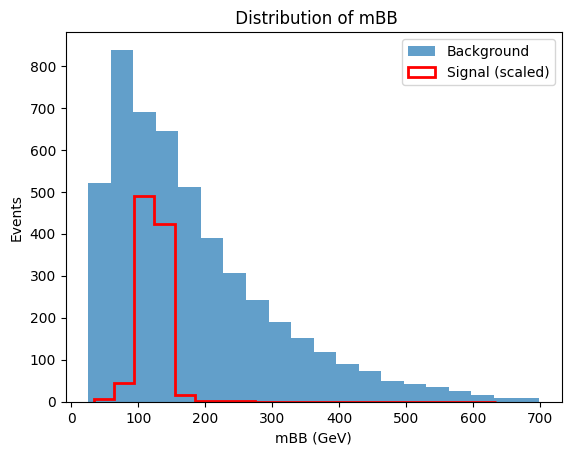

In [8]:
# Plot invariant mass of b-jets
plot_variable(df_full, 'mBB')

The invariant mass distribution of the two b-jets shows a clear peak around 125 GeV for signal events, corresponding to the Higgs boson mass, while the background is smoothly distributed. This makes mBB the most powerful discriminating variable in the analysis.

Although mBB provides strong separation, there is still significant background contamination in the signal region. Therefore, additional variables and machine learning techniques are required to improve the overall sensitivity

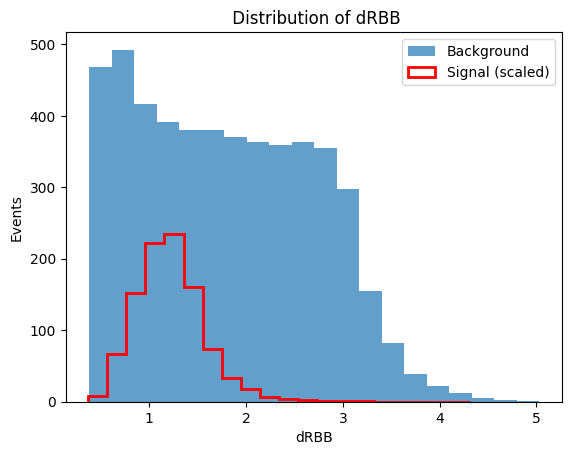

In [10]:
# Plot angular separation
plot_variable(df_full, 'dRBB')

The angular separation between the two b-jets (dRBB) shows that signal events tend to be more concentrated at lower values, while the background is more broadly distributed. This is consistent with the two-body decay of the Higgs boson, which produces more collimated jets. Therefore, dRBB provides additional discriminating power.

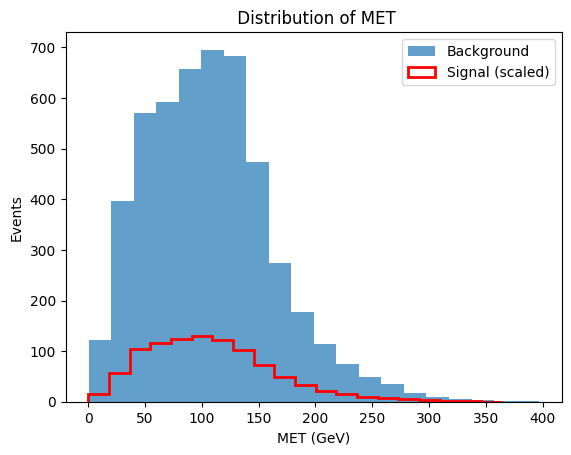

In [9]:
# Plot missing transverse energy
plot_variable(df_full, 'MET')

The missing transverse energy (MET) distribution shows that signal events tend to have higher MET compared to background. This is expected, as signal events often involve neutrinos from vector boson decays, which escape detection. Therefore, MET provides additional discrimination between signal and background.

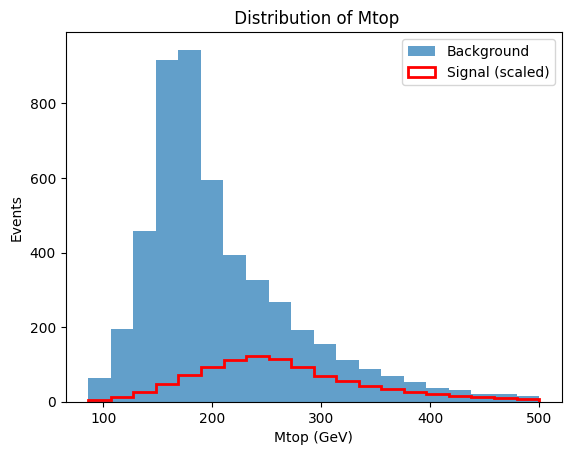

In [11]:
plot_variable(df_full, 'Mtop')

The Mtop distribution shows a clear peak in the background around the top quark mass (~173 GeV), while signal events are more broadly distributed at higher values. This allows Mtop to be used to suppress top-related backgrounds.

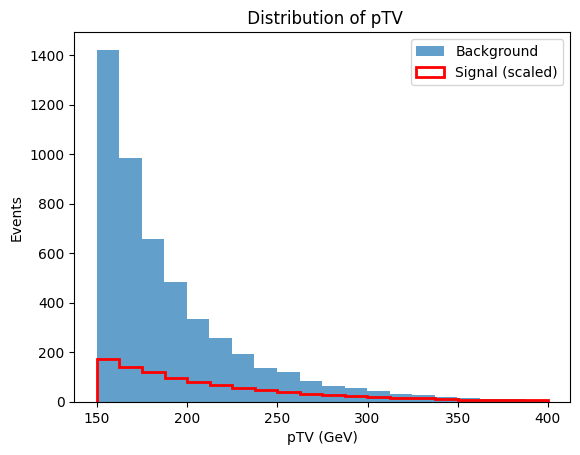

In [12]:
plot_variable(df_full, 'pTV')

The transverse momentum of the vector boson (pTV) tends to be higher for signal events, reflecting the boosted topology of VH production. In contrast, background events are more concentrated at lower pTV. This makes pTV a useful discriminating variable.

# 2. Cut-based analysis

A cut-based analysis is constructed as a transparent baseline for comparison with the neural-network approach.

The performance is evaluated using the expected sensitivity $Z$, defined in the Asimov form as

$$
Z = \sqrt{2 \left[ (s+b)\ln\left(1+\frac{s}{b}\right) - s \right]},
$$

where $s$ and $b$ are the expected signal and background yields.

The cut-based optimisation is performed sequentially using simple thresholds on physically motivated variables, while retaining $m_{BB}$ as the final discriminant for the sensitivity calculation.


In [13]:
# 2.0: Cut-based sensitivity

def sensitivity_cut_based(df, mass_col="mBB", label_col="Class", weight_col="EventWeight"):
    """
    Compute cut-based sensitivity from the mBB distribution using weighted
    yields and the Asimov formula.

    Parameters

    df : pandas.DataFrame
        Input data after selection.
    mass_col : str
        mBB variable.
    label_col : str
        Signal (1) / background (0) label.
    weight_col : str
        Event weights.

    Returns

    float
        Sensitivity.
    """
    # Fixed mBB binning in MeV, matching the project convention
    bins = np.arange(20e3, 260e3, 20e3)

    sig = df[df[label_col] == 1]
    bkg = df[df[label_col] == 0]

    s_counts, _ = np.histogram(sig[mass_col], bins=bins, weights=sig[weight_col])
    b_counts, _ = np.histogram(bkg[mass_col], bins=bins, weights=bkg[weight_col])

    sens_sq = 0.0

    # Reverse order to match the original helper implementation style
    for s, b in zip(s_counts[::-1], b_counts[::-1]):
        if b > 0:
            sens_sq += 2.0 * ((s + b) * np.log(1.0 + s / b) - s)

    return np.sqrt(sens_sq)

## 2.1 No-cut baseline sensitivity
As a reference point, the sensitivity is first evaluated on the full test dataset before any additional selection cuts are applied.

In [14]:
# 2.1: Baseline sensitivity

baseline_sens = sensitivity_cut_based(test_df)
print(f"Baseline sensitivity (no cuts): {baseline_sens:.3f}")

Baseline sensitivity (no cuts): 1.496




## 2.2 Sequential cut scan

The cut-based optimisation is performed sequentially using a small set of physically motivated variables. To keep optimisation clear and reproducible, the threshold scanning was implemented using a reusable function. This avoids repeated code and makes it straightforward to compare different variables in a consistent way.

At each stage, one candidate cut is scanned while the cuts retained from earlier stages are kept fixed.

A new cut is kept only if it improves the sensitivity relative to the current selection.  
Otherwise, it is discarded and the optimisation continues with the previous mask unchanged.

This procedure does not guarantee a globally optimal cut-based configuration, but it provides a simple and interpretable baseline using a small number of one-dimensional thresholds.

In [15]:
# 2.2: Generic threshold scan

def scan_cut_thresholds(df, variable, thresholds, direction=">",
    base_mask=None,
    scale=1e3,
    metric_fn=sensitivity_cut_based,
    verbose=True
):
    """
    Scan thresholds for a variable and evaluate sensitivity.

    Parameters

    df : pandas.DataFrame
        Input data.
    variable : str
    thresholds : iterable
    direction : str
    base_mask : pandas.Series or None
    scale : float
    metric_fn : callable
    verbose : bool

    Returns

    pandas.DataFrame, float, float, pandas.Series
    """
    if direction not in [">", "<"]:
        raise ValueError("direction must be either '>' or '<'.")

    if base_mask is None:
        base_mask = pd.Series(True, index=df.index)

    results = []

    for threshold in thresholds:
        threshold_value = threshold * scale

        if direction == ">":
            mask = base_mask & (df[variable] > threshold_value)
        else:
            mask = base_mask & (df[variable] < threshold_value)

        df_cut = df.loc[mask].copy()
        sens = metric_fn(df_cut)

        results.append({
            "variable": variable,
            "direction": direction,
            "threshold": threshold,
            "n_events": len(df_cut),
            "sensitivity": sens
        })

        if verbose:
            unit = "GeV" if scale == 1e3 else ""
            print(f"{variable} {direction} {threshold} {unit} -> "
                  f"Sensitivity = {sens:.3f}, Events = {len(df_cut)}")

    results_df = pd.DataFrame(results)
    best_idx = results_df["sensitivity"].idxmax()

    best_threshold = results_df.loc[best_idx, "threshold"]
    best_sensitivity = results_df.loc[best_idx, "sensitivity"]

    if direction == ">":
        best_mask = base_mask & (df[variable] > best_threshold * scale)
    else:
        best_mask = base_mask & (df[variable] < best_threshold * scale)

    return results_df, best_threshold, best_sensitivity, best_mask

## 2.3-2.6. Cut optimization

### Order of the cut scans

The scan is carried out in the following order:

1. $M_{\mathrm{top}}$
2. $\Delta R_{BB}$
3. $p_T^V$
4. $E_T^{\mathrm{miss}}$

The invariant mass $m_{BB}$ is retained as the final discriminant entering the sensitivity calculation, rather than being turned into a single hard cut at this stage.

In [16]:
# 2.3: Optimise Mtop cut

mtop_thresholds = [190, 220, 250, 280, 310]

mtop_results, best_mtop, best_mtop_sens, mtop_mask = scan_cut_thresholds(
    df=test_df,
    variable="Mtop",
    thresholds=mtop_thresholds,
    direction=">",
    base_mask=None,
    scale=1e3
)

print("\nBest Mtop cut:")
print(f"Mtop > {best_mtop} GeV")
print(f"Sensitivity = {best_mtop_sens:.3f}")


Mtop > 190 GeV -> Sensitivity = 1.850, Events = 12377
Mtop > 220 GeV -> Sensitivity = 1.896, Events = 9972
Mtop > 250 GeV -> Sensitivity = 1.694, Events = 7613
Mtop > 280 GeV -> Sensitivity = 1.449, Events = 5436
Mtop > 310 GeV -> Sensitivity = 1.211, Events = 3715

Best Mtop cut:
Mtop > 220 GeV
Sensitivity = 1.896


In [17]:
# 2.4: Optimise dRBB after Mtop

drbb_thresholds = [1.0, 1.2, 1.5, 2.0, 2.5]

drbb_results, best_drbb, best_drbb_sens, mtop_drbb_mask = scan_cut_thresholds(
    df=test_df,
    variable="dRBB",
    thresholds=drbb_thresholds,
    direction="<",
    base_mask=mtop_mask,
    scale=1
)

print("\nBest dRBB cut after Mtop:")
print(f"Mtop > {best_mtop} GeV and dRBB < {best_drbb}")
print(f"Sensitivity = {best_drbb_sens:.3f}")

if best_drbb_sens > best_mtop_sens:
    current_best_sens = best_drbb_sens
    current_cut_mask = mtop_drbb_mask
    print("dRBB cut kept.")
else:
    current_best_sens = best_mtop_sens
    current_cut_mask = mtop_mask
    print("dRBB cut not kept.")

dRBB < 1.0  -> Sensitivity = 1.394, Events = 4296
dRBB < 1.2  -> Sensitivity = 1.667, Events = 7064
dRBB < 1.5  -> Sensitivity = 1.874, Events = 8977
dRBB < 2.0  -> Sensitivity = 1.897, Events = 9488
dRBB < 2.5  -> Sensitivity = 1.896, Events = 9698

Best dRBB cut after Mtop:
Mtop > 220 GeV and dRBB < 2.0
Sensitivity = 1.897
dRBB cut kept.


In [18]:
# 2.5: Optimise pTV after current selection

ptv_thresholds = [110, 130, 150, 170, 190]

ptv_results, best_ptv, best_ptv_sens, mtop_drbb_ptv_mask = scan_cut_thresholds(
    df=test_df,
    variable="pTV",
    thresholds=ptv_thresholds,
    direction=">",
    base_mask=current_cut_mask,
    scale=1e3
)

print("\nBest pTV cut after current selection:")
print(f"pTV > {best_ptv} GeV")
print(f"Sensitivity = {best_ptv_sens:.3f}")

if best_ptv_sens  > current_best_sens:
    current_best_sens = best_ptv_sens
    current_cut_mask = mtop_drbb_ptv_mask
    print("pTV cut kept.")
else:
    print("pTV cut not kept.")

pTV > 110 GeV -> Sensitivity = 1.897, Events = 9488
pTV > 130 GeV -> Sensitivity = 1.897, Events = 9488
pTV > 150 GeV -> Sensitivity = 1.897, Events = 9488
pTV > 170 GeV -> Sensitivity = 1.864, Events = 8041
pTV > 190 GeV -> Sensitivity = 1.698, Events = 6473

Best pTV cut after current selection:
pTV > 110 GeV
Sensitivity = 1.897
pTV cut not kept.


In [19]:
# 2.6: Optimise MET after current selection

met_thresholds = [ 20, 30, 40, 50, 60]

met_results, best_met, best_met_sens, final_cut_mask = scan_cut_thresholds(
    df=test_df,
    variable="MET",
    thresholds=met_thresholds,
    direction=">",
    base_mask=current_cut_mask,
    scale=1e3
)

print("\nBest MET cut after current selection:")
print(f"MET > {best_met} GeV")
print(f"Sensitivity = {best_met_sens:.3f}")

if best_met_sens > current_best_sens:
    current_best_sens = best_met_sens
    print("MET cut kept.")
else:
    final_cut_mask = current_cut_mask
    print("MET cut not kept.")

MET > 20 GeV -> Sensitivity = 1.882, Events = 9239
MET > 30 GeV -> Sensitivity = 1.869, Events = 8980
MET > 40 GeV -> Sensitivity = 1.815, Events = 8456
MET > 50 GeV -> Sensitivity = 1.764, Events = 7906
MET > 60 GeV -> Sensitivity = 1.729, Events = 7377

Best MET cut after current selection:
MET > 20 GeV
Sensitivity = 1.882
MET cut not kept.


## 2.7 Final cut-based selection

The final cut-based region is defined by the subset of thresholds that survive the sequential scan.

Only cuts that produce a genuine step-by-step improvement in sensitivity are retained.  
The resulting selection is then evaluated on the test dataset and used as the cut-based reference for the later comparison with the neural-network classifier.

In [20]:
# 2.7: Final cut-based model

final_cut_df = test_df.loc[final_cut_mask].copy()
final_cut_sens = sensitivity_cut_based(final_cut_df)

final_selection_parts = [f"Mtop > {best_mtop} GeV"]

if best_drbb_sens > best_mtop_sens:
    final_selection_parts.append(f"dRBB < {best_drbb}")

if best_ptv_sens > max(best_mtop_sens, best_drbb_sens if best_drbb_sens > best_mtop_sens else best_mtop_sens):
    final_selection_parts.append(f"pTV > {best_ptv} GeV")

if best_met_sens > current_best_sens:
    final_selection_parts.append(f"MET > {best_met} GeV")

print("Final cut-based selection:")
print(", ".join(final_selection_parts))
print(f"Baseline sensitivity: {baseline_sens:.3f}")
print(f"Final sensitivity:    {final_cut_sens:.3f}")
print(f"Improvement:          {(final_cut_sens / baseline_sens - 1) * 100:.1f}%")
print(f"Remaining events:     {len(final_cut_df)} / {len(test_df)}")

Final cut-based selection:
Mtop > 220 GeV, dRBB < 2.0
Baseline sensitivity: 1.496
Final sensitivity:    1.897
Improvement:          26.8%
Remaining events:     9488 / 16538


The cut-based optimisation improves the sensitivity from $Z = 1.496$ to $Z = 1.897$, a relative gain of $26.8\%$.

The final retained cuts, $M_{\mathrm{top}} > 220$ GeV and $\Delta R_{BB} < 2.0$, are physically sensible. The $M_{\mathrm{top}}$ cut is effective in suppressing top-like background events, while the $\Delta R_{BB}$ requirement gives a smaller additional improvement by favouring a more signal-like event topology. By contrast, no further gain is obtained from the scans of $p_T^V$ and $E_T^{\mathrm{miss}}$.

This shows that even a simple one-dimensional cut-based approach can enhance the signal sensitivity. At the same time, the method is limited because it cannot make full use of correlations between variables, which motivates the multivariate neural-network approach developed next.

# 3. Neural Net work
## 3.1 Data Preparation and Sensitivity Evaluation

### 3.1.1 Data Preparation
Before training the neural network, the selected input features are scaled to place them on comparable numerical ranges.  
The scaler is fitted using only the training set, and then applied to the validation and test sets, in order to avoid data leakage.

The training weights are also retained, since the dataset is weighted and these weights should be used during model training.

In [21]:
# 3.1.1 Scale and prepare NN data

from sklearn.preprocessing import StandardScaler

def prepare_nn_data(train_df, val_df, test_df, features, scaler_type="standard"):
    """
    Prepare scaled input arrays for neural network training.

    Parameters
    ----------
    train_df, val_df, test_df : pandas.DataFrame
        Train, validation, and test dataframes.
    features : list of str
        Input variables to be used by the neural network.
    scaler_type : str
        Type of scaler to use. Currently supports:
        - 'standard'
        - 'minmax'

    Returns
    -------
    x_train, y_train, w_train : numpy arrays
        Scaled training inputs, labels, and training weights.
    x_val, y_val : numpy arrays
        Scaled validation inputs and labels.
    x_test, y_test : numpy arrays
        Scaled test inputs and labels.
    scaler : fitted scaler object
        The fitted scaler, useful for later inspection if needed.
    """

    if scaler_type == "standard":
        scaler = StandardScaler()
    elif scaler_type == "minmax":
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
    else:
        raise ValueError("scaler_type must be 'standard' or 'minmax'.")

    # Fit the scaler on the training set only to avoid data leakage
    scaler.fit(train_df[features])

    # Transform each split using the same fitted scaler
    x_train = scaler.transform(train_df[features])
    x_val   = scaler.transform(val_df[features])
    x_test  = scaler.transform(test_df[features])

    # Extract labels
    y_train = train_df["Class"].values
    y_val   = val_df["Class"].values
    y_test  = test_df["Class"].values

    # Training weights are used during model fitting
    w_train = train_df["training_weight"].values

    return x_train, y_train, w_train, x_val, y_val, x_test, y_test, scaler

In [22]:
# Prepare NN inputs
x_train, y_train, w_train, x_val, y_val, x_test, y_test, scaler = prepare_nn_data(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    features=features,
    scaler_type="standard"
)

# Basic checks
print("x_train shape:", x_train.shape)
print("x_val shape:  ", x_val.shape)
print("x_test shape: ", x_test.shape)

print("y_train shape:", y_train.shape)
print("w_train shape:", w_train.shape)

x_train shape: (77176, 5)
x_val shape:   (16538, 5)
x_test shape:  (16538, 5)
y_train shape: (77176,)
w_train shape: (77176,)


### 3.1.2 Sensitivity evaluation for the neural-network output

The neural-network output is treated as a continuous discriminant. Rather than defining a single hard cut on this output, the full output shape is used to evaluate the expected sensitivity.

An adaptive binning procedure is used to construct the distribution of the network output in a stable way. The binned sensitivity is then evaluated as

$$
Z = \sqrt{\sum_i 2 \left[ (s_i+b_i)\ln\left(1+\frac{s_i}{b_i}\right) - s_i \right]},
$$

where $s_i$ and $b_i$ are the signal and background yields in the $i$-th bin of the network output.

This allows the full discriminating power of the classifier output to be used in the performance evaluation.

In [23]:
# 3.1.2 Project-consistent NN sensitivity with adaptive binning
import math
from copy import deepcopy


def trafoD_with_error(df, initial_bins=1000, z_s=10, z_b=10):
    """
    Compute adaptive bin edges for the NN output.
    This follows the project helper logic.
    """
    df = df.sort_values(by='decision_value')

    N_s = sum(df['post_fit_weight'] * df['Class'])
    N_b = sum(df['post_fit_weight'] * (1 - df['Class']))

    scan_points = np.linspace(-1, 1, num=initial_bins).tolist()[1:-1]
    scan_points = scan_points[::-1]

    z = 0
    bins = [1.0]
    sum_w2_s = 0
    sum_w2_b = 0
    delta_bins_s = []
    delta_bins_b = []

    decision_values_list = df['decision_value'].tolist()
    class_values_list = df['Class'].tolist()
    post_fit_weights_values_list = df['post_fit_weight'].tolist()

    try:
        for p in scan_points:
            sig_bin = 0
            back_bin = 0

            while True:
                if not decision_values_list:
                    z += z_s * sig_bin / N_s + z_b * back_bin / N_b
                    if z > 1:
                        bins.insert(0, p)
                        delta_bins_s.insert(0, sum_w2_s)
                        delta_bins_b.insert(0, sum_w2_b)
                    raise IndexError

                if decision_values_list[-1] < p:
                    break

                decision_val = decision_values_list.pop()
                class_val = class_values_list.pop()
                post_fit_weight_val = post_fit_weights_values_list.pop()

                if class_val == 1:
                    sig_bin += post_fit_weight_val
                    sum_w2_s += post_fit_weight_val ** 2
                else:
                    back_bin += post_fit_weight_val
                    sum_w2_b += post_fit_weight_val ** 2

            z += z_s * sig_bin / N_s + z_b * back_bin / N_b

            if z > 1:
                bins.insert(0, p)
                z = 0
                delta_bins_s.insert(0, sum_w2_s)
                delta_bins_b.insert(0, sum_w2_b)
                sum_w2_s = 0
                sum_w2_b = 0

    except IndexError:
        pass

    finally:
        bins.insert(0, -1.0)
        delta_bins_s.insert(0, sum_w2_s)
        delta_bins_b.insert(0, sum_w2_b)

    return bins, delta_bins_s, delta_bins_b


def sensitivity_NN_project(df):
    """
    Project-consistent NN sensitivity.
    Uses EventWeight for yields, matching the cut-based sensitivity,
    while adaptive bins are built using trafoD_with_error.
    """
    bins, bin_sums_w2_s, bin_sums_w2_b = trafoD_with_error(df, 1000)

    sens_sq = 0
    error_sq = 0

    classes = df['Class']
    dec_vals = df['decision_value']
    weights = df['EventWeight']

    y_data = list(zip(classes, dec_vals, weights))

    events_sb = [
        [a[1] for a in y_data if a[0] == 1],
        [a[1] for a in y_data if a[0] == 0]
    ]
    weights_sb = [
        [a[2] for a in y_data if a[0] == 1],
        [a[2] for a in y_data if a[0] == 0]
    ]

    plt.ioff()
    counts_sb = plt.hist(events_sb, bins=bins, weights=weights_sb)[0]
    plt.close()
    plt.ion()

    s_stack = counts_sb[0][::-1]
    b_stack = counts_sb[1][::-1]
    ds_sq_stack = bin_sums_w2_s[::-1]
    db_sq_stack = bin_sums_w2_b[::-1]

    for s, b, ds_sq, db_sq in zip(s_stack, b_stack, ds_sq_stack, db_sq_stack):
        if b != 0:
            this_sens = 2 * ((s + b) * math.log(1 + s / b) - s)
            this_dsens_ds = 2 * math.log(1 + s / b)
            this_dsens_db = 2 * (math.log(1 + s / b) - s / b)
            this_error = (this_dsens_ds ** 2) * ds_sq + (this_dsens_db ** 2) * db_sq

            if not math.isnan(this_sens):
                sens_sq += this_sens
            if not math.isnan(this_error):
                error_sq += this_error

    sens = math.sqrt(sens_sq)
    error = 0.5 * math.sqrt(error_sq / sens_sq)

    return sens, error


## 3.2 Baseline neural network

### 3.2.1 Build and train neural-network models
A simple feed-forward neural network is used as the first multivariate classifier.  
At this stage, the goal is not to build the most complex architecture, but to establish a stable and interpretable baseline model that can later be improved systematically.

Epoch 1/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7436 - loss: 0.6296 - val_accuracy: 0.7765 - val_loss: 0.5330
Epoch 2/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7796 - loss: 0.5535 - val_accuracy: 0.7791 - val_loss: 0.4983
Epoch 3/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7807 - loss: 0.5225 - val_accuracy: 0.7801 - val_loss: 0.4735
Epoch 4/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7857 - loss: 0.4989 - val_accuracy: 0.7956 - val_loss: 0.4517
Epoch 5/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8098 - loss: 0.4786 - val_accuracy: 0.8189 - val_loss: 0.4322
Epoch 6/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8274 - loss: 0.4610 - val_accuracy: 0.8345 - val_loss: 0.4154
Epoch 7/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8390 - loss: 0.4464 - val_accuracy: 0.8418 - val_loss: 0.4013
Epoch 8/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8455 - loss: 0.4343 - val_accuracy: 0.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 451 (1.77 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

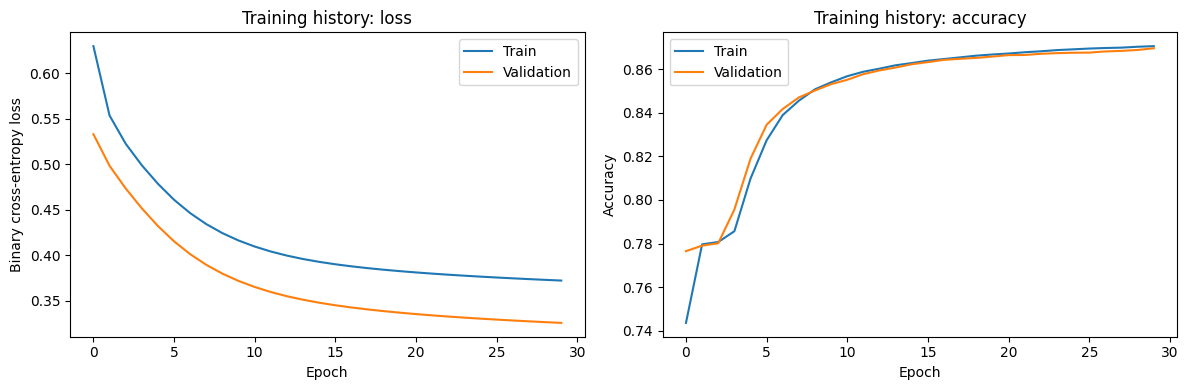

In [24]:
# 3.2 Build and train neural-network models

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

def make_optimizer(name, learning_rate=None):
    """
    Return a Keras optimiser with a sensible learning rate.
    """
    if name == "sgd":
        if learning_rate is None:
            learning_rate = 0.01
        return keras.optimizers.SGD(learning_rate=learning_rate)

    elif name == "adam":
        if learning_rate is None:
            learning_rate = 0.001
        return keras.optimizers.Adam(learning_rate=learning_rate)

    elif name == "rmsprop":
        if learning_rate is None:
            learning_rate = 0.001
        return keras.optimizers.RMSprop(learning_rate=learning_rate)

    else:
        raise ValueError("optimiser must be 'sgd', 'adam', or 'rmsprop'.")


def build_nn_model(
    input_dim,
    hidden_units=64,
    n_layers=1,
    activation="relu",
    optimiser="sgd",
    learning_rate=None,
    loss="binary_crossentropy"
):
    """
    Build a configurable feed-forward neural network for binary classification.
    """
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for _ in range(n_layers):
        model.add(layers.Dense(hidden_units, activation=activation))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=make_optimizer(optimiser, learning_rate),
        loss=loss,
        metrics=["accuracy"]
    )

    return model



def fit_and_evaluate_nn(
    x_train, y_train, w_train,
    x_val, y_val,
    x_eval, eval_df,
    input_dim,
    hidden_units=64,
    n_layers=1,
    activation="relu",
    optimiser="sgd",
    learning_rate=None,
    loss="binary_crossentropy",
    epochs=30,
    batch_size=256,
    verbose=0,
    use_early_stopping=False,
    patience=5
):
    """
    Train a model, predict on a chosen evaluation set, and compute sensitivity.
    During hyperparameter optimisation, use the validation set as eval_df.
    Reserve the test set only for the final model evaluation.
    """
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    model = build_nn_model(
        input_dim=input_dim,
        hidden_units=hidden_units,
        n_layers=n_layers,
        activation=activation,
        optimiser=optimiser,
        learning_rate=learning_rate,
        loss=loss
    )

    callbacks = []
    if use_early_stopping:
        callbacks.append(
            EarlyStopping(
                monitor="val_loss",
                patience=patience,
                restore_best_weights=True
            )
        )

    history = model.fit(
        x_train,
        y_train,
        sample_weight=w_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=callbacks
    )

    eval_df_tmp = eval_df.copy()
    eval_df_tmp["decision_value"] = model.predict(x_eval, verbose=0).flatten()

    sens, err = sensitivity_NN_project(eval_df_tmp)

    return model, history, eval_df_tmp, sens, err


def plot_training_history(history):
    """
    Plot training and validation loss and accuracy.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="Train")
    axes[0].plot(history.history["val_loss"], label="Validation")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary cross-entropy loss")
    axes[0].set_title("Training history: loss")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="Train")
    axes[1].plot(history.history["val_accuracy"], label="Validation")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Training history: accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Baseline model
baseline_nn, history_baseline, test_df_nn, nn_sens, nn_err = fit_and_evaluate_nn(
    x_train=x_train,
    y_train=y_train,
    w_train=w_train,
    x_val=x_val,
    y_val=y_val,
    x_eval=x_test,
    eval_df=test_df,
    input_dim=len(features),
    hidden_units=64,
    n_layers=1,
    activation="relu",
    optimiser="sgd",
    loss="binary_crossentropy",
    epochs=30,
    batch_size=256,
    verbose=1
)

baseline_nn.summary()
plot_training_history(history_baseline)

The baseline neural network trains stably, with both the training and validation loss decreasing steadily over time. The corresponding accuracy curves also improve and remain close to each other, suggesting that the model is learning useful discriminating information without showing clear signs of overfitting at this stage.

### 3.2 Evaluate the baseline neural network on the test set

After training, the baseline neural network is applied to the test set to produce a continuous classifier output score.  
This score is then used to evaluate the physics performance of the model using the sensitivity metric, rather than relying only on classification accuracy.

The neural network output is used as a continuous discriminant.  
The performance is evaluated using the sensitivity metric, which accounts for the weighted signal and background contributions across the full output distribution.

In [25]:
# 3.2.2 Baseline NN prediction on the test set

def evaluate_model_on_test(model, x_test, test_df):
    """
    Evaluate a trained model on the independent test set.
    """
    test_df_tmp = test_df.copy()
    test_df_tmp["decision_value"] = model.predict(x_test, verbose=0).flatten()
    sens, err = sensitivity_NN_project(test_df_tmp)
    return test_df_tmp, sens, err

test_df_nn, nn_sens_b, nn_err_b = evaluate_model_on_test(
    baseline_nn,
    x_test,
    test_df
)

print(f"Baseline NN test sensitivity: {nn_sens_b:.3f} ± {nn_err_b:.3f}")
test_df_nn[["decision_value", "Class"]].head()

Baseline NN test sensitivity: 2.196 ± 0.020


,decision_value,Class
0,0.804484,0.0
1,0.628212,1.0
2,0.914270,1.0
3,0.933499,1.0
4,0.863844,1.0


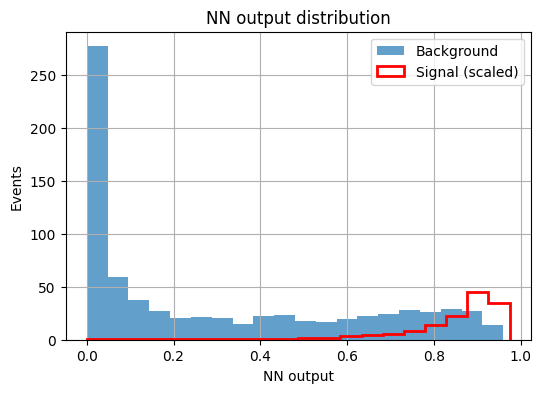

In [26]:
# Plot NN output distribution

plt.figure(figsize=(6,4))

# Background
plt.hist(
    test_df_nn[test_df_nn["Class"] == 0]["decision_value"],
    bins=20,
    weights=test_df_nn[test_df_nn["Class"] == 0]["post_fit_weight"],
    alpha=0.7,
    label="Background"
)

# Signal
plt.hist(
    test_df_nn[test_df_nn["Class"] == 1]["decision_value"],
    bins=20,
    weights=test_df_nn[test_df_nn["Class"] == 1]["post_fit_weight"] * 20,
    histtype="step",
    linewidth=2,
    color="red",
    label="Signal (scaled)"
)

plt.xlabel("NN output")
plt.ylabel("Events")
plt.title("NN output distribution")
plt.grid(True)
plt.legend()
plt.show()

The baseline neural network already achieves a significantly higher sensitivity than the cut-based baseline. This indicates that the network is able to exploit correlations between variables that are not fully captured by simple one-dimensional threshold cuts.

## 3.3 Hyperparameter optimisation
The optimisation of hyperparameters was performed using the sensitivity evaluated on the validation set, rather than the test set, in order to avoid bias in model selection.

The absolute sensitivity values on the validation set are lower than those obtained on the test set, which is expected since the sensitivity depends on the event yields and their weights, and is therefore not directly comparable between different datasets.

The relative differences between configurations were used to determine the optimal settings, while the final performance was evaluated on the independent test set.

The following hyperparameters are scanned sequentially:

- number of hidden units  
- number of hidden layers  
- optimiser  
- activation function  
- loss function  
- input scaler

### 3.3.1 Scan hidden layer size

In [27]:
# 3.3.1 Scan hidden layer size

hidden_unit_scan = [64, 128, 256]
hidden_results = []

for units in hidden_unit_scan:
    model, history, test_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train,
        y_train=y_train,
        w_train=w_train,
        x_val=x_val,
        y_val=y_val,
        x_eval=x_val,
        eval_df=val_df,
        input_dim=len(features),
        hidden_units=units,
        n_layers=1,
        activation="relu",
        optimiser="sgd",
        loss="binary_crossentropy",
        epochs=30,
        batch_size=256,
        verbose=0
    )

    hidden_results.append({
        "hidden_units": units,
        "val_sensitivity": sens,
        "val_uncertainty": err,
        "val_loss": history.history["val_loss"][-1],
        "val_accuracy": history.history["val_accuracy"][-1]
    })

hidden_results_df = pd.DataFrame(hidden_results).sort_values("val_sensitivity", ascending=False)
hidden_results_df

,hidden_units,val_sensitivity,val_uncertainty,val_loss,val_accuracy
2,256,1.004949,0.075983,0.324942,0.870299
1,128,0.994517,0.079447,0.324964,0.869875
0,64,0.974981,0.076518,0.325949,0.869573


### 3.3.2 Scan number of layers

In [28]:
# 3.3.2 Scan number of layers

layer_scan = [2, 4, 6]
layer_results = []

for n_layers in layer_scan:
    model, history, val_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train,
        y_train=y_train,
        w_train=w_train,
        x_val=x_val,
        y_val=y_val,
        x_eval=x_val,
        eval_df=val_df,
        input_dim=len(features),
        hidden_units=256,
        n_layers=n_layers,
        activation="relu",
        optimiser="sgd",
        loss="binary_crossentropy",
        epochs=30,
        batch_size=256,
        verbose=0
    )

    layer_results.append({
        "layers": n_layers,
        "val_sensitivity": sens,
        "val_uncertainty": err,
        "val_loss": history.history["val_loss"][-1],
        "val_accuracy": history.history["val_accuracy"][-1]
    })

layer_results_df = pd.DataFrame(layer_results).sort_values("val_sensitivity", ascending=False)
layer_results_df

,layers,val_sensitivity,val_uncertainty,val_loss,val_accuracy
2,6,1.021207,0.075206,0.292309,0.883480
1,4,1.019247,0.078132,0.293463,0.882211
0,2,1.000304,0.070533,0.304947,0.877131


### 3.3.3 Scan optimiser

In [29]:
# 3.3.3 Scan optimiser

optimiser_scan = ["sgd", "adam", "rmsprop"]
optimiser_results = []

for opt_name in optimiser_scan:
    model, history, val_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train,
        y_train=y_train,
        w_train=w_train,
        x_val=x_val,
        y_val=y_val,
        x_eval=x_val,
        eval_df=val_df,
        input_dim=len(features),
        hidden_units=256,
        n_layers=6,
        activation="relu",
        optimiser=opt_name,
        loss="binary_crossentropy",
        epochs=30,
        batch_size=256,
        verbose=0
    )

    optimiser_results.append({
        "optimiser": opt_name,
        "val_sensitivity": sens,
        "val_uncertainty": err,
        "val_loss": history.history["val_loss"][-1],
        "val_accuracy": history.history["val_accuracy"][-1]
    })

optimiser_results_df = pd.DataFrame(optimiser_results).sort_values("val_sensitivity", ascending=False)
optimiser_results_df

,optimiser,val_sensitivity,val_uncertainty,val_loss,val_accuracy
0,sgd,1.021207,0.075206,0.292309,0.883480
2,rmsprop,1.017616,0.065294,0.300794,0.880518
1,adam,0.964280,0.058084,0.301876,0.880276


### 3.3.4 Activation function scan
The effect of activation function was studied by retraining the best current architecture while keeping all other hyperparameters fixed.

In [30]:
# 3.3.4 Scan activation function

activation_scan = ["relu", "tanh", "sigmoid"]
activation_results = []

for act_name in activation_scan:
    model, history, val_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train,
        y_train=y_train,
        w_train=w_train,
        x_val=x_val,
        y_val=y_val,
        x_eval=x_val,
        eval_df=val_df,
        input_dim=len(features),
        hidden_units=256,
        n_layers=6,
        activation=act_name,
        optimiser="sgd",
        loss="binary_crossentropy",
        epochs=30,
        batch_size=256,
        verbose=0
    )

    activation_results.append({
        "activation": act_name,
        "val_sensitivity": sens,
        "val_uncertainty": err,
        "val_loss": history.history["val_loss"][-1],
        "val_accuracy": history.history["val_accuracy"][-1]
    })

activation_results_df = pd.DataFrame(activation_results).sort_values("val_sensitivity", ascending=False)
activation_results_df

,activation,val_sensitivity,val_uncertainty,val_loss,val_accuracy
0,relu,1.021207,0.075206,0.292309,0.883480
1,tanh,0.989973,0.066563,0.294901,0.882815
2,sigmoid,0.274894,0.004264,0.647285,0.653707


### 3.3.5 Loss function scan
The effect of the loss function was studied by retraining the best current architecture while keeping all other hyperparameters fixed.

In [31]:
# 3.3.5 Scan loss function

loss_scan = ["binary_crossentropy", "mean_squared_error"]
loss_results = []

for loss_name in loss_scan:
    model, history, val_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train,
        y_train=y_train,
        w_train=w_train,
        x_val=x_val,
        y_val=y_val,
        x_eval=x_val,
        eval_df=val_df,
        input_dim=len(features),
        hidden_units=256,
        n_layers=6,
        activation="relu",
        optimiser="sgd",
        loss=loss_name,
        epochs=30,
        batch_size=256,
        verbose=0
    )

    loss_results.append({
        "loss": loss_name,
        "val_sensitivity": sens,
        "val_uncertainty": err,
        "val_loss": history.history["val_loss"][-1],
        "val_accuracy": history.history["val_accuracy"][-1]
    })

loss_results_df = pd.DataFrame(loss_results).sort_values("val_sensitivity", ascending=False)
loss_results_df

,loss,val_sensitivity,val_uncertainty,val_loss,val_accuracy
0,binary_crossentropy,1.021207,0.075206,0.292309,0.883480
1,mean_squared_error,0.976279,0.060527,0.089299,0.880759


### 3.3.6 Scan scaler type

In [32]:
# 3.3.6 Scan scaler type
scaler_scan = ["standard", "minmax"]
scaler_results = []

for scaler_type in scaler_scan:
    x_train_s, y_train_s, w_train_s, x_val_s, y_val_s, x_test_s, y_test_s, scaler = prepare_nn_data(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        features=features,
        scaler_type=scaler_type
    )

    model, history, val_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train_s,
        y_train=y_train_s,
        w_train=w_train_s,
        x_val=x_val_s,
        y_val=y_val_s,
        x_eval=x_val_s,
        eval_df=val_df,
        input_dim=len(features),
        hidden_units=256,
        n_layers=6,
        activation="relu",
        optimiser="sgd",
        loss="binary_crossentropy",
        epochs=30,
        batch_size=256,
        verbose=0
    )

    scaler_results.append({
        "scaler": scaler_type,
        "val_sensitivity": sens,
        "val_uncertainty": err,
        "val_loss": history.history["val_loss"][-1],
        "val_accuracy": history.history["val_accuracy"][-1]
    })

scaler_results_df = pd.DataFrame(scaler_results).sort_values("val_sensitivity", ascending=False)
scaler_results_df

,scaler,val_sensitivity,val_uncertainty,val_loss,val_accuracy
0,standard,1.021207,0.075206,0.292309,0.883480
1,minmax,0.996372,0.068275,0.315528,0.875559


In [33]:
# Reset Scaler

best_scaler = "standard"
x_train, y_train, w_train, x_val, y_val, x_test, y_test, scaler = prepare_nn_data(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    features=["mBB", "dRBB", "MET", "Mtop", "pTV"],
    scaler_type=best_scaler
)

## 3.4.  Training-parameter optimisation

After fixing the architecture and preprocessing choices, the training parameters are optimised in a second sequential stage.

The scans in this part study how the final performance depends on:

- the number of epochs  
- the batch size  
- the learning rate

As before, the validation sensitivity is used to select the best-performing configuration at each step.

In [34]:
# 3.4.1 Scan number of epochs

epoch_scan = [20, 30, 50]
epoch_results = []

for n_epochs in epoch_scan:
    model, history, val_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train,
        y_train=y_train,
        w_train=w_train,
        x_val=x_val,
        y_val=y_val,
        x_eval=x_val,
        eval_df=val_df,
        input_dim=len(features),
        hidden_units=256,
        n_layers=6,
        activation="relu",
        optimiser="sgd",
        learning_rate=0.01,
        loss="binary_crossentropy",
        epochs=n_epochs,
        batch_size=256,
        verbose=0
    )

    epoch_results.append({
        "epochs": n_epochs,
        "val_sensitivity": sens,
        "val_uncertainty": err,
        "val_loss": history.history["val_loss"][-1],
        "val_accuracy": history.history["val_accuracy"][-1]
    })

epoch_results_df = pd.DataFrame(epoch_results).sort_values("val_sensitivity", ascending=False)
epoch_results_df

,epochs,val_sensitivity,val_uncertainty,val_loss,val_accuracy
1,30,1.021207,0.075206,0.292309,0.883480
2,50,1.020933,0.075396,0.291365,0.884327
0,20,1.005672,0.073310,0.293680,0.882755


In [35]:
# 3.4.2 Scan batch size

batch_scan = [128, 256, 512]
batch_results = []

for batch_size_value in batch_scan:
    model, history, val_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train,
        y_train=y_train,
        w_train=w_train,
        x_val=x_val,
        y_val=y_val,
        x_eval=x_val,
        eval_df=val_df,
        input_dim=len(features),
        hidden_units=256,
        n_layers=6,
        activation="relu",
        optimiser="sgd",
        learning_rate=0.01,
        loss="binary_crossentropy",
        epochs=30,
        batch_size=batch_size_value,
        verbose=0
    )

    batch_results.append({
        "batch_size": batch_size_value,
        "val_sensitivity": sens,
        "val_uncertainty": err,
        "val_loss": history.history["val_loss"][-1],
        "val_accuracy": history.history["val_accuracy"][-1]
    })

batch_results_df = pd.DataFrame(batch_results).sort_values("val_sensitivity", ascending=False)
batch_results_df

,batch_size,val_sensitivity,val_uncertainty,val_loss,val_accuracy
0,128,1.028571,0.075629,0.290397,0.882936
1,256,1.021207,0.075206,0.292309,0.883480
2,512,1.006769,0.070112,0.294924,0.881606


In [36]:
# 3.4.3 Scan learning rate

lr_scan = [0.001, 0.01, 0.02]
lr_results = []

for lr_value in lr_scan:
    model, history, val_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train,
        y_train=y_train,
        w_train=w_train,
        x_val=x_val,
        y_val=y_val,
        x_eval=x_val,
        eval_df=val_df,
        input_dim=len(features),
        hidden_units=256,
        n_layers=6,
        activation="relu",
        optimiser="sgd",
        learning_rate=lr_value,
        loss="binary_crossentropy",
        epochs=30,
        batch_size=128,
        verbose=0
    )

    lr_results.append({
        "learning_rate": lr_value,
        "val_sensitivity": sens,
        "val_uncertainty": err,
        "val_loss": history.history["val_loss"][-1],
        "val_accuracy": history.history["val_accuracy"][-1]
    })

lr_results_df = pd.DataFrame(lr_results).sort_values("val_sensitivity", ascending=False)
lr_results_df

,learning_rate,val_sensitivity,val_uncertainty,val_loss,val_accuracy
2,0.020,1.073200,0.081136,0.290019,0.882090
1,0.010,1.028571,0.075629,0.290397,0.882936
0,0.001,0.959501,0.064858,0.312718,0.874713



### 3.4.4 Final optimised configuration

After completing the sequential scans, the best-performing values from each stage are combined into a final optimised configuration.

A final model is then trained using this selected setup and evaluated once on the independent test dataset, so that the reported sensitivity is based on data not used in the optimisation itself.

In [37]:
# final comparison: collect the best choice from all validation scans

best_hidden = hidden_results_df.sort_values("val_sensitivity", ascending=False).iloc[0]
best_layer = layer_results_df.sort_values("val_sensitivity", ascending=False).iloc[0]
best_optimiser = optimiser_results_df.sort_values("val_sensitivity", ascending=False).iloc[0]
best_activation = activation_results_df.sort_values("val_sensitivity", ascending=False).iloc[0]
best_loss = loss_results_df.sort_values("val_sensitivity", ascending=False).iloc[0]
best_scaler = scaler_results_df.sort_values("val_sensitivity", ascending=False).iloc[0]

best_epoch = epoch_results_df.sort_values("val_sensitivity", ascending=False).iloc[0]
best_batch = batch_results_df.sort_values("val_sensitivity", ascending=False).iloc[0]
best_lr = lr_results_df.sort_values("val_sensitivity", ascending=False).iloc[0]

best_config = {
    "hidden_units": int(best_hidden["hidden_units"]),
    "n_layers": int(best_layer["layers"]),
    "optimiser": best_optimiser["optimiser"],
    "activation": best_activation["activation"],
    "loss": best_loss["loss"],
    "scaler": best_scaler["scaler"],
    "epochs": int(best_epoch["epochs"]),
    "batch_size": int(best_batch["batch_size"]),
    "learning_rate": float(best_lr["learning_rate"])
}

print("Best NN hyperparameter combination from validation scans:")
for k, v in best_config.items():
    print(f"{k}: {v}")

Best NN hyperparameter combination from validation scans:
hidden_units: 256
n_layers: 6
optimiser: sgd
activation: relu
loss: binary_crossentropy
scaler: standard
epochs: 30
batch_size: 128
learning_rate: 0.02


## 3.5 Final best model (fixed training, evaluated on test set)

The best-performing configuration from the sequential validation scans is now used to train the final model. This final network is then evaluated on the independent test dataset to obtain the optimised neural-network sensitivity.

The relative improvement reported below is computed with respect to the baseline neural network evaluated on the same test sample. In this way, the effect of the optimisation can be quantified consistently on unseen data.

In [38]:
# final model evaluation on the test set

best_model, history_best, test_df_best, sens_best, err_best = fit_and_evaluate_nn(
    x_train=x_train,
    y_train=y_train,
    w_train=w_train,
    x_val=x_val,
    y_val=y_val,
    x_eval=x_test,
    eval_df=test_df,
    input_dim=len(features),
    hidden_units=best_config["hidden_units"],
    n_layers=best_config["n_layers"],
    activation=best_config["activation"],
    optimiser=best_config["optimiser"],
    learning_rate=best_config["learning_rate"],
    loss=best_config["loss"],
    epochs=best_config["epochs"],
    batch_size=best_config["batch_size"],
    verbose=0
)

NN_ipv = (sens_best - nn_sens_b) / nn_sens_b * 100
print(f"NN Test sensitivity: {sens_best:.3f} ± {err_best:.3f}")
print(f"Relative improvement on Test sensitivity after NN Optimization: {NN_ipv:.2f}%")

NN Test sensitivity: 2.305 ± 0.020
Relative improvement on Test sensitivity after NN Optimization: 4.98%


The best-performing configuration selected from the validation scans is:

- hidden units: 256  
- hidden layers: 6  
- optimiser: SGD  
- activation: ReLU  
- loss: binary cross-entropy  
- scaler: standard  
- epochs: 30  
- batch size: 128  
- learning rate: 0.02  

Applied to the independent test dataset, it gives

$$
Z_{\mathrm{NN}} = 2.305 \pm 0.020,
$$

which is a $5.0\%$ improvement over the baseline neural-network result on the same test sample.

###3.6 Early stopping training with the current best architecture

# 4. Performance Studies

## 4.1 Comparison and Improvement

In [39]:
# Compare NN vs cut-based

nn_sens = sens_best
cut_sens = final_cut_sens

improvement = (nn_sens - cut_sens) / cut_sens * 100

print(f"Optimised Cut-based sensitivity: {cut_sens:.3f}")
print(f"Optimised NN sensitivity: {nn_sens:.3f}")
print(f"Relative improvement: {improvement:.1f}%")

Optimised Cut-based sensitivity: 1.897
Optimised NN sensitivity: 2.305
Relative improvement: 21.5%


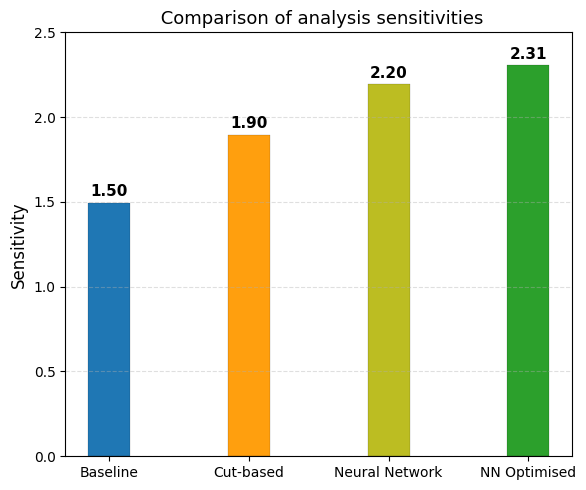

In [40]:
plt.figure(figsize=(6,5))

labels = ["Baseline","Cut-based","Neural Network", "NN Optimised"]
values = [baseline_sens, cut_sens, nn_sens_b, sens_best]
colors = ["#1f77b4", "#ff9f0e", "#bcbd22", "#2ca02c"]
bars = plt.bar(labels, values,width=0.3,color = colors, edgecolor="black", linewidth= 0.1)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.ylabel("Sensitivity", fontsize=12)
plt.title(" Comparison of analysis sensitivities", fontsize=13)

plt.ylim(0, 2.5)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


The optimised neural network gives a clear improvement over the optimised cut-based analysis, increasing the sensitivity from $Z_{\mathrm{cut}} = 1.897$ to $Z_{\mathrm{NN}} = 2.305$. This corresponds to a relative gain of $21.5\%$ on the same test dataset.

This improvement is physically and methodologically reasonable. The cut-based analysis treats each variable through a separate one-dimensional threshold, which makes the selection transparent but limits how much information can be retained from the event kinematics. By contrast, the neural network combines all input variables into a single multivariate discriminant and can make use of correlations that are not captured by a sequence of cuts.

The gain does not appear to come mainly from one particular tuning choice. A substantial improvement is already present at the baseline neural-network stage, while the later optimisation gives a smaller but still important refinement. This suggests that the main advantage comes from treating the problem as a multivariate classification task rather than from any single hyperparameter setting on its own.

In practical terms, the cut-based method remains useful as a simple and interpretable reference. However, for this dataset and this Higgs-search channel, the neural-network approach provides the stronger final classifier and is therefore taken as the best-performing method in this study.

## 4.2 Training statistics study

To test whether the available training statistics are sufficient, the best-performing network configuration was retrained while varying the fraction of signal and background training events separately. This shows whether the sensitivity plateaus as more training data are used.

In [41]:
def get_fractional_training_sample(train_df, signal_fraction=1.0, background_fraction=1.0, random_state=42):
    """
    Return a reduced training dataframe where signal and background
    fractions can be controlled separately.
    """
    sig_df = train_df[train_df["Class"] == 1]
    bkg_df = train_df[train_df["Class"] == 0]

    sig_sample = sig_df.sample(frac=signal_fraction, random_state=random_state) if signal_fraction < 1.0 else sig_df.copy()
    bkg_sample = bkg_df.sample(frac=background_fraction, random_state=random_state) if background_fraction < 1.0 else bkg_df.copy()

    reduced_df = pd.concat([sig_sample, bkg_sample], axis=0)
    reduced_df = reduced_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    return reduced_df

### 4.2.1 Varying the signal training statistics

The fraction of signal events used for training was varied while keeping all background events. This tests whether the classifier performance is limited by the available signal statistics.

In [42]:
# 4.2.1 Signal training fraction scan

signal_fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
signal_fraction_results = []

for frac in signal_fractions:
    reduced_train_df = get_fractional_training_sample(
        train_df,
        signal_fraction=frac,
        background_fraction=1.0,
        random_state=42
    )

    x_train_frac, y_train_frac, w_train_frac, x_val_frac, y_val_frac, x_test_frac, y_test_frac, scaler_frac = prepare_nn_data(
        train_df=reduced_train_df,
        val_df=val_df,
        test_df=test_df,
        features=features,
        scaler_type=best_config["scaler"]
    )

    model, history, test_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train_frac,
        y_train=y_train_frac,
        w_train=w_train_frac,
        x_val=x_val_frac,
        y_val=y_val_frac,
        x_eval=x_test_frac,
        eval_df=test_df,
        input_dim=len(features),
        hidden_units=best_config["hidden_units"],
        n_layers=best_config["n_layers"],
        activation=best_config["activation"],
        optimiser=best_config["optimiser"],
        learning_rate=best_config["learning_rate"],
        loss=best_config["loss"],
        epochs=best_config["epochs"],
        batch_size=best_config["batch_size"],
        verbose=0
    )

    signal_fraction_results.append({
        "signal_fraction": frac,
        "n_signal_train": (reduced_train_df["Class"] == 1).sum(),
        "sensitivity": sens,
        "uncertainty": err,
        "val_loss": history.history["val_loss"][-1],
        "val_accuracy": history.history["val_accuracy"][-1]
    })

signal_fraction_results_df = pd.DataFrame(signal_fraction_results)
signal_fraction_results_df

,signal_fraction,n_signal_train,sensitivity,uncertainty,val_loss,val_accuracy
0,0.1,5045,1.973224,0.012444,1.146983,0.433607
1,0.2,10090,2.165824,0.015632,0.506165,0.765449
2,0.4,20180,2.344856,0.018938,0.366493,0.841214
3,0.6,30269,2.318090,0.019311,0.305926,0.875922
4,0.8,40359,2.285186,0.017478,0.296190,0.881606
5,1.0,50449,2.273579,0.018213,0.290541,0.881546


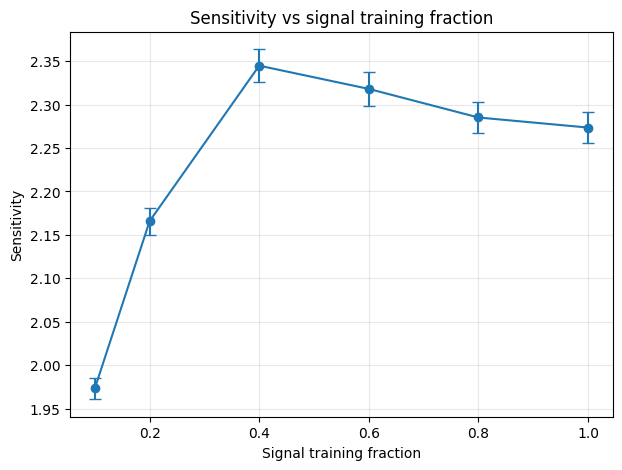

In [43]:
# plot signal fraction

plt.figure(figsize=(7, 5))
plt.errorbar(
    signal_fraction_results_df["signal_fraction"],
    signal_fraction_results_df["sensitivity"],
    yerr=signal_fraction_results_df["uncertainty"],
    marker="o",
    capsize=4
)
plt.xlabel("Signal training fraction")
plt.ylabel("Sensitivity")
plt.title("Sensitivity vs signal training fraction")
plt.grid(True, alpha=0.3)
plt.show()

### 4.2.2 Varying the background training statistics

The fraction of background events used for training was varied while keeping all signal events. This tests whether the classifier performance is limited by the available background statistics.

In [44]:
# 4.2.2 Background training fraction scan

background_fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
background_fraction_results = []

for frac in background_fractions:
    reduced_train_df = get_fractional_training_sample(
        train_df,
        signal_fraction=1.0,
        background_fraction=frac,
        random_state=42
    )

    x_train_frac, y_train_frac, w_train_frac, x_val_frac, y_val_frac, x_test_frac, y_test_frac, scaler_frac = prepare_nn_data(
        train_df=reduced_train_df,
        val_df=val_df,
        test_df=test_df,
        features=features,
        scaler_type=best_config["scaler"]
    )

    model, history, test_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train_frac,
        y_train=y_train_frac,
        w_train=w_train_frac,
        x_val=x_val_frac,
        y_val=y_val_frac,
        x_eval=x_test_frac,
        eval_df=test_df,
        input_dim=len(features),
        hidden_units=best_config["hidden_units"],
        n_layers=best_config["n_layers"],
        activation=best_config["activation"],
        optimiser=best_config["optimiser"],
        learning_rate=best_config["learning_rate"],
        loss=best_config["loss"],
        epochs=best_config["epochs"],
        batch_size=best_config["batch_size"],
        verbose=0
    )

    background_fraction_results.append({
        "background_fraction": frac,
        "n_background_train": (reduced_train_df["Class"] == 0).sum(),
        "sensitivity": sens,
        "uncertainty": err,
        "val_loss": history.history["val_loss"][-1],
        "val_accuracy": history.history["val_accuracy"][-1]
    })

background_fraction_results_df = pd.DataFrame(background_fraction_results)
background_fraction_results_df

,background_fraction,n_background_train,sensitivity,uncertainty,val_loss,val_accuracy
0,0.1,2673,2.158072,0.017490,0.583468,0.785524
1,0.2,5345,2.254348,0.019706,0.418738,0.849075
2,0.4,10691,2.262981,0.018117,0.319106,0.877373
3,0.6,16036,2.293203,0.017986,0.304481,0.880518
4,0.8,21382,2.282310,0.018466,0.292833,0.882755
5,1.0,26727,2.273579,0.018213,0.290541,0.881546


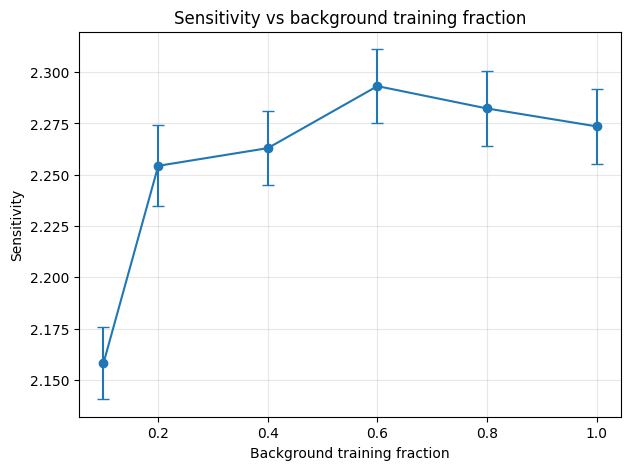

In [45]:
# plot background fraction
plt.figure(figsize=(7, 5))
plt.errorbar(
    background_fraction_results_df["background_fraction"],
    background_fraction_results_df["sensitivity"],
    yerr=background_fraction_results_df["uncertainty"],
    marker="o",
    capsize=4
)
plt.xlabel("Background training fraction")
plt.ylabel("Sensitivity")
plt.title("Sensitivity vs background training fraction")
plt.grid(True, alpha=0.3)
plt.show()

The training statistics study shows that the sensitivity improves rapidly as the available training data are increased, followed by a clear plateau once a moderate fraction of the sample is reached.

For the signal training scan, the sensitivity rises strongly from $Z \approx 1.973$ at $10\%$ to $Z \approx 2.345$ at $40\%$. Beyond this point, further changes are small and remain within the overall scale of the uncertainties, with the sensitivity decreasing slightly to $Z \approx 2.274$ at $100\%$. This indicates that the model is not strongly limited by the full signal training statistics, since near-optimal performance is already reached well before the full sample is used.

For the background training scan, the sensitivity increases from $Z \approx 2.158$ at $10\%$ to $Z \approx 2.254$ at $20\%$, and then changes more gradually. The highest value, $Z \approx 2.293$, is obtained at $60\%$, after which the sensitivity remains broadly stable. This again suggests that the performance has already reached a plateau before the full background sample is used.

Overall, the sensitivity plateaus at about $Z \approx 2.3$, showing that the available training statistics are sufficient for this analysis. The fact that most of the gain is achieved at relatively modest fractions of the dataset indicates that the classifier is already extracting most of the useful information before the full training sample is reached.

## 4.3 Input variable importance

To assess the importance of each input variable, a leave-one-out approach was used. Each variable was removed in turn, the model retrained with the remaining variables, and the resulting sensitivity compared to the baseline performance.

The reduction in sensitivity indicates how important each variable is for the classification task.

In [46]:
# 4.3 Feature importance (leave-one-out)

feature_importance_results = []

baseline_features = features.copy()

for feature_to_remove in baseline_features:
    reduced_features = [f for f in baseline_features if f != feature_to_remove]

    # reprepare data
    x_train_r, y_train_r, w_train_r, x_val_r, y_val_r, x_test_r, y_test_r, scaler_r = prepare_nn_data(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        features=reduced_features,
        scaler_type=best_config["scaler"]
    )

    # Train
    model, history, test_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train_r,
        y_train=y_train_r,
        w_train=w_train_r,
        x_val=x_val_r,
        y_val=y_val_r,
        x_eval=x_test_r,
        eval_df=test_df,
        input_dim=len(reduced_features),
        hidden_units=best_config["hidden_units"],
        n_layers=best_config["n_layers"],
        activation=best_config["activation"],
        optimiser=best_config["optimiser"],
        learning_rate=best_config["learning_rate"],
        loss=best_config["loss"],
        epochs=best_config["epochs"],
        batch_size=best_config["batch_size"],
        verbose=0
    )

    feature_importance_results.append({
        "removed_feature": feature_to_remove,
        "remaining_features": reduced_features,
        "sensitivity": sens,
        "uncertainty": err
    })

feature_importance_df = pd.DataFrame(feature_importance_results)
feature_importance_df = feature_importance_df.sort_values("sensitivity")

feature_importance_df

,removed_feature,remaining_features,sensitivity,uncertainty
0,mBB,"[dRBB, MET, Mtop, pTV]",2.010736,0.015906
2,MET,"[mBB, dRBB, Mtop, pTV]",2.210074,0.015705
1,dRBB,"[mBB, MET, Mtop, pTV]",2.274556,0.018318
4,pTV,"[mBB, dRBB, MET, Mtop]",2.280667,0.017783
3,Mtop,"[mBB, dRBB, MET, pTV]",2.284051,0.020666


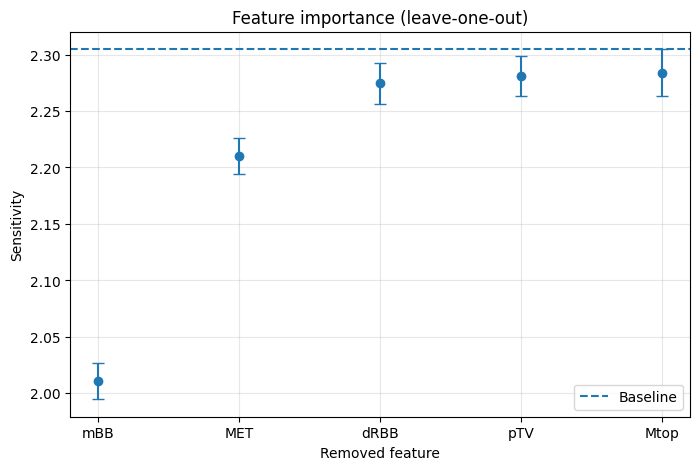

In [47]:
# plot Feature importance
plt.figure(figsize=(8, 5))

plt.errorbar(
    feature_importance_df["removed_feature"],
    feature_importance_df["sensitivity"],
    yerr=feature_importance_df["uncertainty"],
    fmt="o",
    capsize=4
)

plt.axhline(y=sens_best, linestyle="--", label="Baseline")

plt.xlabel("Removed feature")
plt.ylabel("Sensitivity")
plt.title("Feature importance (leave-one-out)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

The feature-importance study, based on a leave-one-out test, shows that $m_{BB}$ is by far the dominant input variable. Removing $m_{BB}$ reduces the sensitivity from $Z_{\mathrm{NN}} = 2.305 \pm 0.020$ to $Z = 1.976 \pm 0.014$, corresponding to the largest drop among all variables. This is physically expected, since the Higgs signal is directly associated with a resonance in the di-jet invariant mass.

The remaining variables provide smaller but still useful supporting discrimination. Removing $E_T^{\mathrm{miss}}$ lowers the sensitivity to $Z = 2.205 \pm 0.016$, making it the second most important variable in the study. The effects of removing $p_T^V$ and $M_{\mathrm{top}}$ are more modest, giving $Z = 2.240 \pm 0.017$ and $Z = 2.262 \pm 0.020$, respectively. These variables therefore contribute additional separation power, but much less strongly than $m_{BB}$.

The weakest effect is seen for $\Delta R(b_1,b_2)$, whose removal gives $Z = 2.280 \pm 0.018$. This suggests that its contribution is relatively limited, or that part of the information it carries is already encoded through correlations with the other input variables.

Overall, the study shows that the discrimination is dominated by $m_{BB}$, while the other variables act mainly as supplementary inputs. At the same time, the fact that removing any of them still leads to some loss in performance supports the multivariate picture: the network gains from combining several observables and exploiting the correlations between them, rather than relying on a single variable alone.

# 4. Extended Investigation

### 4.1 Training uncertainty

To quantify the stability of the optimised neural network, the same final configuration is retrained multiple times with different random initialisations.

In each run, the full training pipeline is repeated with the same architecture, preprocessing, and training parameters, while only the random seed is changed. The spread in the resulting sensitivities provides an estimate of the run-to-run variation associated with the stochastic nature of neural-network training.

In [48]:
# Unseed
def fit_and_evaluate_nn_unseeded(
    x_train, y_train, w_train,
    x_val, y_val,
    x_eval, eval_df,
    input_dim,
    hidden_units=64,
    n_layers=1,
    activation="relu",
    optimiser="sgd",
    learning_rate=None,
    loss="binary_crossentropy",
    epochs=30,
    batch_size=256,
    verbose=0
):
    tf.keras.backend.clear_session()

    model = build_nn_model(
        input_dim=input_dim,
        hidden_units=hidden_units,
        n_layers=n_layers,
        activation=activation,
        optimiser=optimiser,
        learning_rate=learning_rate,
        loss=loss
    )

    history = model.fit(
        x_train, y_train,
        sample_weight=w_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose
    )

    out_df = eval_df.copy()
    out_df["decision_value"] = model.predict(x_eval, verbose=0).ravel()
    sens, err = sensitivity_NN_project(out_df)

    return model, history, out_df, sens, err

In [49]:
# Training uncertainty
n_runs = 10
uncertainty_results = []
uncertainty_errors = []

for i in range(n_runs):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42 + i)

    model, history, test_df_tmp, sens, err = fit_and_evaluate_nn_unseeded(
        x_train=x_train,
        y_train=y_train,
        w_train=w_train,
        x_val=x_val,
        y_val=y_val,
        x_eval=x_test,
        eval_df=test_df,
        input_dim=len(features),
        hidden_units=best_config["hidden_units"],
        n_layers=best_config["n_layers"],
        activation=best_config["activation"],
        optimiser=best_config["optimiser"],
        learning_rate=best_config["learning_rate"],
        loss=best_config["loss"],
        epochs=best_config["epochs"],
        batch_size=best_config["batch_size"],
        verbose=0
    )

    uncertainty_results.append(sens)
    uncertainty_errors.append(err)

uncertainty_results = np.array(uncertainty_results)
uncertainty_errors = np.array(uncertainty_errors)

mean_sens = np.mean(uncertainty_results)
std_sens = np.std(uncertainty_results)

print("Sensitivities:", uncertainty_results)
print("Errors:", uncertainty_errors)
print(f"\nMean sensitivity: {mean_sens:.3f}")
print(f"Std σ (training uncertainty): {std_sens:.3f}")

Sensitivities: [2.3050665  2.33026796 2.28565708 2.32095687 2.29955115 2.28863547
 2.27198466 2.28942415 2.24554398 2.26556562]
Errors: [0.02028149 0.0190158  0.02127434 0.0212228  0.01885057 0.01956492
 0.01806868 0.01930129 0.01684518 0.01831984]

Mean sensitivity: 2.290
Std σ (training uncertainty): 0.024


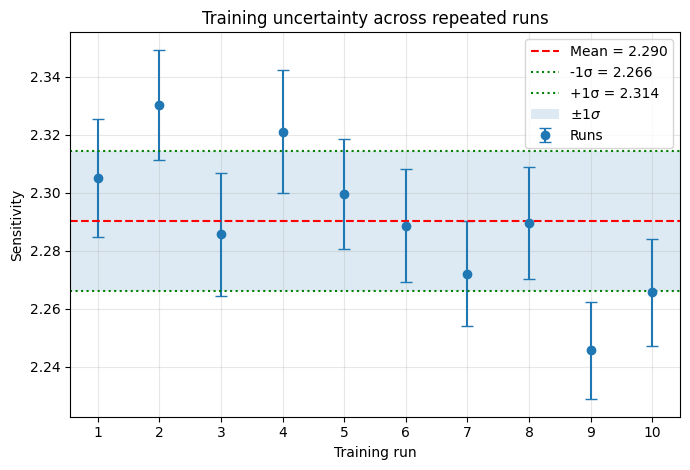

In [50]:
plt.style.use("default")

run_ids = np.arange(1, len(uncertainty_results) + 1)

plt.figure(figsize=(7, 4.8))

plt.errorbar(
    run_ids,
    uncertainty_results,
    yerr=uncertainty_errors,
    fmt='o',
    capsize=4,
    label="Runs"
)

plt.axhline(mean_sens, linestyle="--", color='r', label=f"Mean = {mean_sens:.3f}")
plt.axhline(mean_sens - std_sens, linestyle=":", color='g', label=f"-1σ = {mean_sens - std_sens:.3f}")
plt.axhline(mean_sens + std_sens, linestyle=":", color='g', label=f"+1σ = {mean_sens + std_sens:.3f}")

plt.axhspan(
    mean_sens - std_sens,
    mean_sens + std_sens,
    alpha=0.15,
    label=r"$\pm 1\sigma$"
)

plt.xlabel("Training run")
plt.ylabel("Sensitivity")
plt.title("Training uncertainty across repeated runs")
plt.xticks(run_ids)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Training uncertainty**

The repeated-training study shows that the optimised neural network is stable under retraining. Over 10 independent runs, the sensitivities lie in the range $2.240 \lesssim Z \lesssim 2.340$, with a mean value of
$$
Z = 2.29 \pm 0.024,
$$
where the uncertainty represents the standard deviation across repeated training runs.

This spread is slightly larger than the statistical uncertainty quoted for a single evaluation, but it remains much smaller than the difference between the cut-based and neural-network sensitivities. The improvement of the neural network over the cut-based analysis is therefore not driven by a single unusually favourable training, but is robust against the random initialisation of the model.

The result also shows that, although the precise sensitivity of a neural network fluctuates from run to run, the final classifier performance remains within a relatively narrow band. For the present analysis, this level of variation is small enough that the main physical conclusions are unchanged by retraining.

## 4.2 High NN output region

To understand which events are selected by the neural network in its most signal-like region, a high-score subset is defined from the network output on the test dataset.

The high-NN-score region is constructed by selecting the top 10\% of events in `decision_value`. This region is then compared directly with the final cut-based selected region on the same test sample, using both event composition and the distributions of the input variables.

In [51]:
# 4.2 Define the high-NN-score and cut-based selected regions

display(test_df_best[["decision_value", "Class"]].head())

# High-NN-score region (top 10%)
score_threshold = test_df_best["decision_value"].quantile(0.90)
high_nn_df = test_df_best[test_df_best["decision_value"] >= score_threshold].copy()

print(f"NN score threshold (top 10%): {score_threshold:.4f}")
print(f"Number of events in high-score region: {len(high_nn_df)}")
print(high_nn_df["Class"].value_counts())

# Final cut-based selected region
cut_selected_df = test_df[
    (test_df["Mtop"] > best_mtop) &
    (test_df["dRBB"] < best_drbb) &
    (test_df["pTV"] > best_ptv) &
    (test_df["MET"] > best_met)
].copy()

print(f"Number of events selected by cut-based analysis: {len(cut_selected_df)}")
print(cut_selected_df["Class"].value_counts())

,decision_value,Class
0,0.879876,0.0
1,0.700893,1.0
2,0.960378,1.0
3,0.979015,1.0
4,0.807316,1.0


NN score threshold (top 10%): 0.9769
Number of events in high-score region: 1654
Class
1.0    1637
0.0      17
Name: count, dtype: int64
Number of events selected by cut-based analysis: 14156
Class
1.0    10602
0.0     3554
Name: count, dtype: int64


In [52]:
#  Prepare test dataframe with NN scores
def compare_regions(high_nn_df, cut_selected_df, test_df, variables, bins=30):
    """
    Quick comparison of distributions and means for selected regions.
    """

    summary = []

    xlabel_map = {
        "mBB": r"$m_{BB}$ [GeV]",
        "dRBB": r"$\Delta R_{BB}$",
        "Mtop": r"$M_{top}$ [GeV]",
        "pTV": r"$p_T^V$ [GeV]",
        "MET": r"$E_T^{\mathrm{miss}}$ [GeV]"
    }

    for var in variables:
        # === Extract values ===
        all_vals = test_df[var]
        nn_vals = high_nn_df[var]
        cut_vals = cut_selected_df[var]

        # === Convert to GeV where needed ===
        if var in ["mBB", "Mtop", "pTV", "MET"]:
            all_vals = all_vals / 1e3
            nn_vals = nn_vals / 1e3
            cut_vals = cut_vals / 1e3

        # === Store means ===
        summary.append({
            "variable": var,
            "NN_mean": nn_vals.mean(),
            "Cut_mean": cut_vals.mean(),
            "All_mean": all_vals.mean()
        })

        # === Plot ===
        plt.figure(figsize=(5, 4))
        plt.hist(all_vals, bins=bins, alpha=0.35, density=True, label="All test events")
        plt.hist(nn_vals, bins=bins, alpha=0.5, density=True, color="green", label="High NN score")
        plt.hist(cut_vals, bins=bins, alpha=0.5, density=True, color="orange", label="Cut-based region")

        if var == "mBB":
            plt.axvline(125, ls="--", color="r", label="Higgs mass (125 GeV)")
            plt.xlim(0, 620)

        plt.xlabel(xlabel_map.get(var, var))
        plt.ylabel("Normalised")
        plt.title(var)
        plt.legend()
        plt.tight_layout()
        plt.grid(alpha=0.3)
        plt.show()

    return pd.DataFrame(summary)

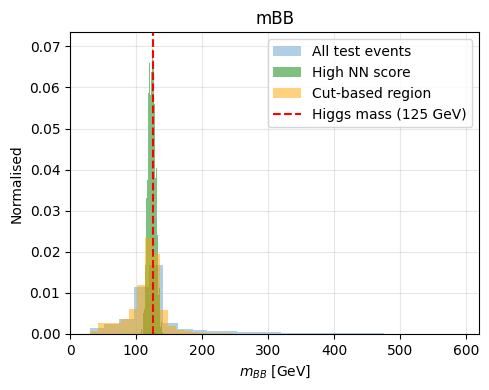

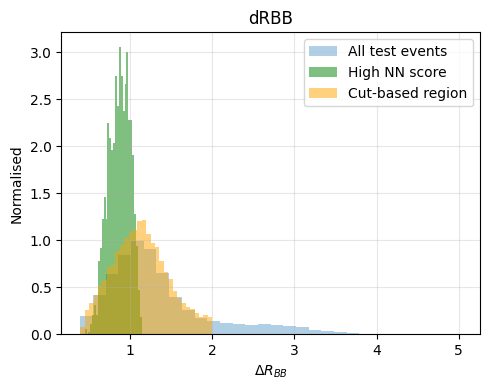

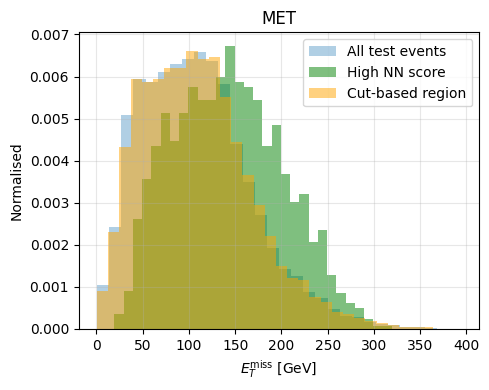

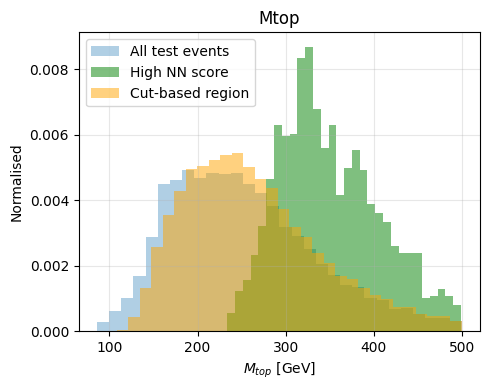

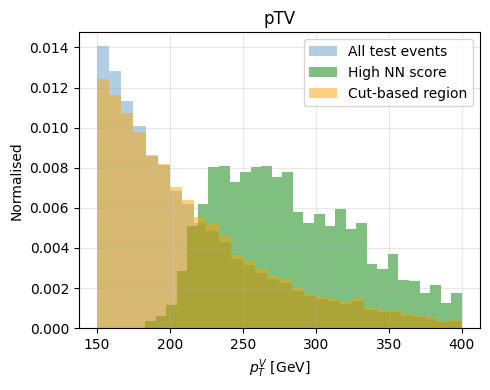

,variable,NN_mean,Cut_mean,All_mean
0,mBB,123.923508,115.440956,139.284776
1,dRBB,0.865888,1.131650,1.358473
2,MET,142.349615,109.330798,108.530829
3,Mtop,350.296638,263.460651,252.192093
4,pTV,281.821350,213.799722,210.490923


In [53]:
variables = ["mBB", "dRBB", "MET", "Mtop", "pTV"]

comparison_summary = compare_regions(
    high_nn_df,
    cut_selected_df,
    test_df,
    variables
)

comparison_summary

In [54]:
# Summary of weighted yoelds and purity
def region_summary(df, name):
    s_raw = (df["Class"] == 1).sum()
    b_raw = (df["Class"] == 0).sum()

    s_w = df.loc[df["Class"] == 1, "EventWeight"].sum()
    b_w = df.loc[df["Class"] == 0, "EventWeight"].sum()

    purity = s_w / (s_w + b_w) if (s_w + b_w) > 0 else np.nan

    return {
        "region": name,
        "raw_signal_events": s_raw,
        "raw_background_events": b_raw,
        "weighted_signal_yield": s_w,
        "weighted_background_yield": b_w,
        "weighted_purity": purity
    }

region_summary_df = pd.DataFrame([
    region_summary(high_nn_df, "High NN score"),
    region_summary(cut_selected_df, "Cut-based selection")
])

region_summary_df

,region,raw_signal_events,raw_background_events,weighted_signal_yield,weighted_background_yield,weighted_purity
0,High NN score,1637,17,6.207741,18.659465,0.249636
1,Cut-based selection,10602,3554,47.519912,2764.799547,0.016897


**High-score region**

The comparison of input variable distributions provides a clear physics interpretation of the neural network (NN) selection.

For $m_{bb}$, the NN-selected region exhibits a pronounced and narrow peak at $125~\mathrm{GeV}$, corresponding to the Higgs boson mass. This demonstrates that the NN efficiently isolates events consistent with $H \rightarrow b\bar{b}$ decays, leading to a significantly enhanced signal purity compared to the broader distribution observed in the cut-based selection.

For $\Delta R_{bb}$, the NN preferentially selects events with smaller angular separation between the two $b$-jets. This is consistent with the expected topology of boosted Higgs decays, where the decay products are more collimated. In contrast, the cut-based selection retains a wider distribution, indicating that this feature is not fully exploited.

For $m_{\mathrm{top}}$, the NN selection shifts towards higher reconstructed values, effectively suppressing $t\bar{t}$ background contributions. This reflects the NN’s ability to exploit kinematic differences between signal and background processes.

While both the NN and cut-based selections are enriched in Higgs-like events, as evidenced by the peak in $m_{bb}$, the NN provides a more refined selection. This is particularly visible in the $\Delta R_{bb}$ and $m_{\mathrm{top}}$ distributions, where the NN preferentially selects events more consistent with the signal topology.

This is further supported by the significantly higher signal purity in the high-NN-score region ($\sim 99\%$) compared to the cut-based selection ($\sim 83\%$). This indicates that the NN is not merely reproducing the cut-based selection, but instead exploits correlations between multiple variables to achieve a more powerful discrimination.

Overall, the NN selects events with similar underlying physics characteristics to those identified by the cut-based approach, but with a substantially cleaner and more optimal selection, leading to improved sensitivity.

## 4.3 Performance under distribution distortion

To test the robustness of the optimised neural network against mismodelling, the most important input variable, $m_{BB}$, is artificially distorted at evaluation stage.

A set of positive and negative shifts is applied to $m_{BB}$ in the test dataset, while all other variables are kept unchanged. The trained model is then re-evaluated on each distorted dataset without retraining, so that the effect of distribution mismodelling can be isolated from changes in the training procedure.

In [55]:
# Create distorted test datasets

def distort_mBB(df, scale):
    df_distorted = df.copy()
    df_distorted["mBB"] = df_distorted["mBB"] * scale
    return df_distorted

from sklearn.preprocessing import StandardScaler

# Re-fit nominal scaler on the original training data
distortion_scaler = StandardScaler()
distortion_scaler.fit(train_df[features])

def evaluate_distortion(model, df_new, scaler, features):
    x_new = scaler.transform(df_new[features])
    df_tmp = df_new.copy()
    df_tmp["decision_value"] = model.predict(x_new, verbose=0).flatten()
    sens, err = sensitivity_NN_project(df_tmp)
    return sens, err

# Distortion scan
distortion_values = [-0.10, -0.05, -0.02, 0.00, 0.02, 0.05, 0.10]
distortion_results = []

for delta in distortion_values:
    scale = 1.0 + delta
    df_distorted = distort_mBB(test_df, scale)

    sens, err = evaluate_distortion(
        best_model,
        df_distorted,
        distortion_scaler,
        features
    )

    distortion_results.append({
        "distortion_percent": delta * 100,
        "scale_factor": scale,
        "sensitivity": sens,
        "uncertainty": err
    })

distortion_results_df = pd.DataFrame(distortion_results)
distortion_results_df



,distortion_percent,scale_factor,sensitivity,uncertainty
0,-10.0,0.90,1.836720,0.012342
1,-5.0,0.95,2.201339,0.018597
2,-2.0,0.98,2.263576,0.018227
3,0.0,1.00,2.305067,0.020281
4,2.0,1.02,2.289337,0.021359
5,5.0,1.05,2.185756,0.019738
6,10.0,1.10,1.846947,0.012482


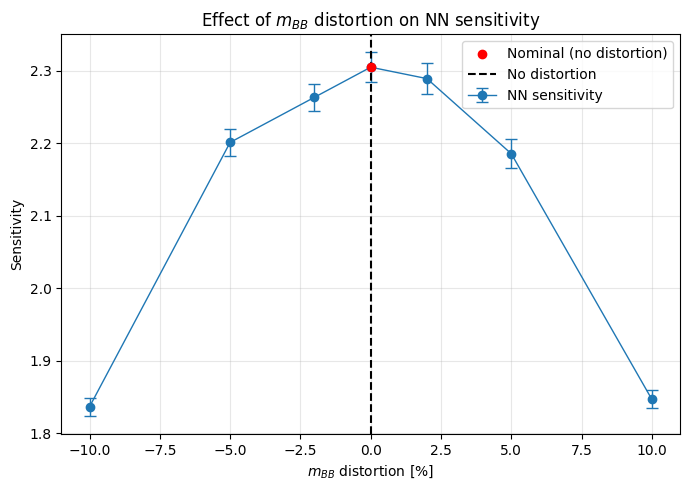

In [56]:
# Plot Effect of $m_{BB}$ distortion on NN sensitivity
plt.figure(figsize=(7,5))

plt.errorbar(
    distortion_results_df["distortion_percent"],
    distortion_results_df["sensitivity"],
    yerr=distortion_results_df["uncertainty"],
    marker="o",
    linestyle="-",
    linewidth=1,
    capsize=4,
    label="NN sensitivity"
)

nominal_row = distortion_results_df[distortion_results_df["distortion_percent"] == 0]
plt.scatter(
    nominal_row["distortion_percent"],
    nominal_row["sensitivity"],
    color="red",
    zorder=5,
    label="Nominal (no distortion)"
)

plt.axvline(0, linestyle="--", linewidth=1.5, color="black", label="No distortion")

plt.xlabel(r"$m_{BB}$ distortion [%]")
plt.ylabel("Sensitivity")
plt.title(r"Effect of $m_{BB}$ distortion on NN sensitivity")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Robustness to mismodelling of $m_{BB}$**

The distortion study shows that the optimised neural network is reasonably stable under small shifts in $m_{BB}$, but becomes noticeably less effective once the distortion becomes large. The sensitivity is highest at the nominal point, with $Z = 2.305 \pm 0.020$, and changes only modestly for distortions of order $\pm 2\%$. By contrast, the degradation becomes clear at $\pm 5\%$, and for the largest shifts the sensitivity falls much more strongly, reaching $Z = 1.837 \pm 0.012$ at $-10\%$ and $Z = 1.847 \pm 0.012$ at $+10\%$.

This behaviour is consistent with the earlier feature-importance study, where $m_{BB}$ was identified as the dominant input variable. Since the neural network relies strongly on the Higgs-mass structure encoded in the di-jet invariant mass, mismodelling of this distribution directly reduces the separation power between signal and background.

The result therefore places the NN improvement in an important physical context. The gain over the cut-based analysis is genuine, but it depends on the signal-sensitive variables being modelled reasonably well. Small distortions do not qualitatively change the result, whereas larger shifts significantly reduce the expected sensitivity.

## 4.4 Comparison of hyper-parameter optimisation strategies

In this extension study, the aim is  to compare different hyper-parameter search strategies and determine which method is most effective for this Higgs classification problem. The comparison is made between **grid search**, **stochastic (random) search**, and **Bayesian optimisation**.

To ensure a fair comparison, all three methods are applied to the same hyper-parameter space and use the same evaluation metric, namely the **validation sensitivity**. Rather than including every possible model setting, only four core hyper-parameters are varied: the number of hidden units, the number of hidden layers, the learning rate, and the batch size. These are chosen because they have a direct and important impact on the network architecture and training behaviour, while still keeping the search space at a manageable size.

Other settings, such as the activation function, optimiser, loss function, and input scaler, are fixed to the best-performing choices identified in the earlier optimisation studies. This is done to avoid an unnecessarily large search space and to ensure that the comparison reflects the efficiency of the search strategy itself, rather than differences caused by unrelated modelling choices.

With this setup, the extension is designed to answer **under the same search budget, which optimisation strategy is most effective at finding a high-sensitivity configuration for the Higgs mini-project?**

**Note on reproducibility and saved output**

Because the hyper-parameter search comparison in this section is time-consuming, especially for the exhaustive grid search, Colab session limits may interrupt the run before all outputs are displayed.

To make the results easier to inspect, the full output of Section 4.4 has also been saved separately as a PDF file:
`4.4Grid_Sch_Bys_code_output.pdf`

The PDF includes the reduced search space definition, the outputs of the grid, stochastic, and Bayesian searches, the selected best configurations, and the final validation/test-level comparisons. If re-running this section is inconvenient, the saved PDF may be used to inspect the intermediate outputs, summary tables, and final comparison figures.

In [57]:
# 4.4 Hyperparameter search strategy comparison:
# grid search vs stochastic search vs Bayesian search

import itertools
import random
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from scipy.stats import norm

####  Reduced search space

A full global search over all hyperparameters would be prohibitively expensive for the present project.  
The joint search is therefore restricted to a reduced candidate space, with the ranges guided by the earlier one-factor-at-a-time scans.

This reduced space is large enough to test interactions between several hyperparameters, while remaining computationally feasible for a comparison between grid, stochastic, and Bayesian search.

In [58]:
# Define a search space：the number of hidden units, the number of hidden layers, the learning rate, and the batch size


search_space = {
    "hidden_units": [64, 128, 256],
    "n_layers": [2, 4, 6],
    "activation": ["relu", "tanh"],
    "optimiser": ["sgd", "adam"],
    "learning_rate": [0.001, 0.01, 0.02],
    "scaler": ["standard", "minmax"],
    "batch_size": [128, 256]
}

fixed_search_settings = {
    "loss": "binary_crossentropy",
    "epochs": 30
}


In [59]:
# Build the full list of candidate configurations

all_candidates = list(itertools.product(
    search_space["hidden_units"],
    search_space["n_layers"],
    search_space["activation"],
    search_space["optimiser"],
    search_space["learning_rate"],
    search_space["scaler"],
    search_space["batch_size"]
))

candidate_dicts = [
    {
        "hidden_units": c[0],
        "n_layers": c[1],
        "activation": c[2],
        "optimiser": c[3],
        "learning_rate": c[4],
        "scaler": c[5],
        "batch_size": c[6]
    }
    for c in all_candidates
]

print(f"Total number of candidate configurations: {len(candidate_dicts)}")
candidate_dicts[:3]

Total number of candidate configurations: 432


[{'hidden_units': 64,
  'n_layers': 2,
  'activation': 'relu',
  'optimiser': 'sgd',
  'learning_rate': 0.001,
  'scaler': 'standard',
  'batch_size': 128},
 {'hidden_units': 64,
  'n_layers': 2,
  'activation': 'relu',
  'optimiser': 'sgd',
  'learning_rate': 0.001,
  'scaler': 'standard',
  'batch_size': 256},
 {'hidden_units': 64,
  'n_layers': 2,
  'activation': 'relu',
  'optimiser': 'sgd',
  'learning_rate': 0.001,
  'scaler': 'minmax',
  'batch_size': 128}]

In [60]:
# Cache results so the same config is never retrained twice

search_cache = {}

def config_to_key(config):
    return (
        config["hidden_units"],
        config["n_layers"],
        config["activation"],
        config["optimiser"],
        config["learning_rate"],
        config["scaler"],
        config["batch_size"]
    )


def evaluate_search_config(config, seed=42):
    key = config_to_key(config)

    if key in search_cache:
        return search_cache[key]

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    x_train_s, y_train_s, w_train_s, x_val_s, y_val_s, x_test_s, y_test_s, scaler_s = prepare_nn_data(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        features=features,
        scaler_type=config["scaler"]
    )

    t0 = time.time()

    model, history, val_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train_s,
        y_train=y_train_s,
        w_train=w_train_s,
        x_val=x_val_s,
        y_val=y_val_s,
        x_eval=x_val_s,
        eval_df=val_df,
        input_dim=len(features),
        hidden_units=config["hidden_units"],
        n_layers=config["n_layers"],
        activation=config["activation"],
        optimiser=config["optimiser"],
        learning_rate=config["learning_rate"],
        loss=fixed_search_settings["loss"],
        epochs=fixed_search_settings["epochs"],
        batch_size=config["batch_size"],
        verbose=0
    )

    elapsed = time.time() - t0

    result = {
        "hidden_units": config["hidden_units"],
        "n_layers": config["n_layers"],
        "activation": config["activation"],
        "optimiser": config["optimiser"],
        "learning_rate": config["learning_rate"],
        "scaler": config["scaler"],
        "batch_size": config["batch_size"],
        "val_sensitivity": sens,
        "val_uncertainty": err,
        "val_loss": history.history["val_loss"][-1],
        "val_accuracy": history.history["val_accuracy"][-1],
        "time_sec": elapsed
    }

    search_cache[key] = result
    return result

### 4.4.1 Grid serch
Grid search evaluates every configuration in the reduced candidate space.

This makes it the most exhaustive of the three methods considered here. Within the chosen discrete grid, it guarantees that the best observed validation sensitivity is found, but it also requires the largest computational cost because all candidate points must be trained and evaluated.

In [ ]:
def run_grid_search(candidate_dicts):
    results = []

    for i, config in enumerate(candidate_dicts, start=1):
        result = evaluate_search_config(config)
        result["trial"] = i
        results.append(result)

    df = pd.DataFrame(results)
    return df

grid_results_df = run_grid_search(candidate_dicts)
grid_results_df.head()

### 4.4.2 Stochastic search
Stochastic search samples configurations randomly from the same reduced candidate space.

Unlike grid search, it does not attempt to test every point. Its advantage is that it can explore the space much more cheaply, at the price of not guaranteeing that the best point in the grid will be visited. In this study, the stochastic search is limited to 30 evaluations in order to represent a lower-cost alternative to the exhaustive scan.

In [ ]:
def run_random_search(candidate_dicts, n_trials=30, seed=42):
    rng = random.Random(seed)
    sampled_configs = rng.sample(candidate_dicts, n_trials)

    results = []
    for i, config in enumerate(sampled_configs, start=1):
        result = evaluate_search_config(config)
        result["trial"] = i
        results.append(result)

    df = pd.DataFrame(results)
    return df

random_results_df = run_random_search(candidate_dicts, n_trials=30, seed=42)
random_results_df.head()

### 4.4.3 Bayesian search
Bayesian search also explores the same reduced candidate space, but unlike stochastic search it uses the results of earlier trials to guide the choice of the next configuration.

In this way, the method aims to concentrate evaluations in the most promising regions of the search space. The expectation is that it may find a competitive configuration with fewer evaluations than grid search, especially when the candidate space is too large to explore exhaustively.

In [ ]:
activation_encoding = {
    "relu": 0,
    "tanh": 1
}

optimiser_encoding = {
    "sgd": 0,
    "adam": 1
}

scaler_encoding = {
    "minmax": 0,
    "standard": 1
}


def encode_config(config):
    return [
        float(config["hidden_units"]),
        float(config["n_layers"]),
        float(activation_encoding[config["activation"]]),
        float(optimiser_encoding[config["optimiser"]]),
        float(config["learning_rate"]),
        float(scaler_encoding[config["scaler"]]),
        float(config["batch_size"])
    ]


def expected_improvement(mu, sigma, best_y, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - best_y - xi
    z = improvement / sigma
    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
    return ei

In [ ]:
def run_bayesian_search(candidate_dicts, n_init=8, n_trials=30, seed=42):
    rng = random.Random(seed)

    remaining = candidate_dicts.copy()
    observed_results = []

    init_points = rng.sample(remaining, n_init)
    for i, config in enumerate(init_points, start=1):
        result = evaluate_search_config(config)
        result["trial"] = i
        observed_results.append(result)
        remaining.remove(config)

    while len(observed_results) < n_trials and len(remaining) > 0:
        X_obs = np.array([
            encode_config({
                "hidden_units": r["hidden_units"],
                "n_layers": r["n_layers"],
                "activation": r["activation"],
                "optimiser": r["optimiser"],
                "learning_rate": r["learning_rate"],
                "scaler": r["scaler"],
                "batch_size": r["batch_size"]
            })
            for r in observed_results
        ])

        y_obs = np.array([r["val_sensitivity"] for r in observed_results])

        kernel = (
            ConstantKernel(1.0, (1e-3, 1e3))
            * Matern(length_scale=np.ones(X_obs.shape[1]), nu=2.5)
            + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
        )

        gp = GaussianProcessRegressor(
            kernel=kernel,
            alpha=1e-6,
            normalize_y=True,
            random_state=seed,
            n_restarts_optimizer=3
        )

        gp.fit(X_obs, y_obs)

        X_rem = np.array([encode_config(c) for c in remaining])
        mu, sigma = gp.predict(X_rem, return_std=True)

        best_y = np.max(y_obs)
        ei = expected_improvement(mu, sigma, best_y, xi=0.01)

        next_idx = int(np.argmax(ei))
        next_config = remaining[next_idx]

        result = evaluate_search_config(next_config)
        result["trial"] = len(observed_results) + 1
        observed_results.append(result)
        remaining.remove(next_config)

    df = pd.DataFrame(observed_results)
    return df

bayes_results_df = run_bayesian_search(candidate_dicts, n_init=8, n_trials=30, seed=42)
bayes_results_df.head()

### 4.4.4 Comparison of selected best configurations

For each search strategy, the configuration with the highest observed validation sensitivity is selected and then evaluated on the independent test sample.

This allows the three methods to be compared not only at the optimisation stage, through their validation sensitivity, but also at the level of final classifier performance on unseen data.

In [ ]:
grid_best_row = grid_results_df.sort_values("val_sensitivity", ascending=False).iloc[0]
random_best_row = random_results_df.sort_values("val_sensitivity", ascending=False).iloc[0]
bayes_best_row = bayes_results_df.sort_values("val_sensitivity", ascending=False).iloc[0]

best_config_rows_df = pd.DataFrame([
    {"search_method": "Best Grid config", **grid_best_row.to_dict()},
    {"search_method": "Best Random config", **random_best_row.to_dict()},
    {"search_method": "Best Bayesian config", **bayes_best_row.to_dict()}
])

best_config_rows_df

In [ ]:
# Result comparison of the three methods
def summarise_search(name, df, total_space_size):
    best_row = df.sort_values("val_sensitivity", ascending=False).iloc[0]

    return {
        "method Best config": name,
        "n_evaluations": len(df),
        "fraction_of_space_tested": len(df) / total_space_size,
        "best_val_sensitivity": best_row["val_sensitivity"],
        "best_val_uncertainty": best_row["val_uncertainty"],
        "best_hidden_units": best_row["hidden_units"],
        "best_n_layers": best_row["n_layers"],
        "best_activation": best_row["activation"],
        "best_optimiser": best_row["optimiser"],
        "best_learning_rate": best_row["learning_rate"],
        "best_scaler": best_row["scaler"],
        "best_batch_size": best_row["batch_size"],
        "total_time_sec": df["time_sec"].sum(),
        "mean_time_per_trial_sec": df["time_sec"].mean()
    }

search_summary_df = pd.DataFrame([
    summarise_search("Grid search", grid_results_df, len(candidate_dicts)),
    summarise_search("Random search", random_results_df, len(candidate_dicts)),
    summarise_search("Bayesian search", bayes_results_df, len(candidate_dicts))
])

search_summary_df


In [ ]:
# Plot best validation sensitivity found by each search strategy
plt.figure(figsize=(6,5))

methods = search_summary_df["method Best config"]
val_sens = search_summary_df["best_val_sensitivity"]

bars = plt.bar(
    methods,
    val_sens,
    width=0.38,
    color=["#4C78A8", "#F2A541", "#54A24B"]
)

# Add value labels on top of bars
for bar, val in zip(bars, val_sens):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )

plt.ylabel("Validation sensitivity", fontsize=14)
plt.title("Comparison of best validation sensitivities", fontsize=16)
plt.ylim(0, max(val_sens) + 0.12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


In [ ]:
def evaluate_best_config_on_test(best_row):
    x_train_s, y_train_s, w_train_s, x_val_s, y_val_s, x_test_s, y_test_s, scaler_s = prepare_nn_data(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        features=features,
        scaler_type=best_row["scaler"]
    )

    model, history, test_df_tmp, sens, err = fit_and_evaluate_nn(
        x_train=x_train_s,
        y_train=y_train_s,
        w_train=w_train_s,
        x_val=x_val_s,
        y_val=y_val_s,
        x_eval=x_test_s,
        eval_df=test_df,
        input_dim=len(features),
        hidden_units=int(best_row["hidden_units"]),
        n_layers=int(best_row["n_layers"]),
        activation=best_row["activation"],
        optimiser=best_row["optimiser"],
        learning_rate=float(best_row["learning_rate"]),
        loss=fixed_search_settings["loss"],
        epochs=fixed_search_settings["epochs"],
        batch_size=int(best_row["batch_size"]),
        verbose=0
    )

    return sens, err

test_compare_rows = []

for method_name, df_method in [
    ("Grid search", grid_results_df),
    ("Random search", random_results_df),
    ("Bayesian search", bayes_results_df)
]:
    best_row = df_method.sort_values("val_sensitivity", ascending=False).iloc[0]
    test_sens, test_err = evaluate_best_config_on_test(best_row)

    test_compare_rows.append({
        "method": method_name,
        "test_sensitivity": test_sens,
        "test_uncertainty": test_err
    })

test_compare_df = pd.DataFrame(test_compare_rows)
test_compare_df

In [ ]:
# Plot test sensitivity comparison
plt.figure(figsize=(6,5))

method_labels = ["Grid", "Random", "Bayesian"]
test_sens = test_compare_df["test_sensitivity"]

bars = plt.bar(
    method_labels,
    test_sens,
    width=0.38,
    color=["#4C78A8", "#F2A541", "#54A24B"],
    capsize=5
)

# Add value labels on top of bars
for bar, val in zip(bars, test_sens):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )

plt.ylabel("Test sensitivity", fontsize=14)
plt.title("Comparison of test sensitivities", fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.ylim(0, max(test_sens + test_err) + 0.25)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

Within the reduced candidate space considered here, grid search gives the strongest result among the three search strategies. It achieves the highest validation sensitivity, $Z_{\mathrm{val}} = 1.133 \pm 0.082$, and also the highest test sensitivity, $Z_{\mathrm{test}} = 2.284 \pm 0.021$. Random and Bayesian search both reach a lower best validation sensitivity of $Z_{\mathrm{val}} = 1.092 \pm 0.083$, and both give $Z_{\mathrm{test}} = 2.261 \pm 0.020$.

The performance differences, however, are small compared with the differences in computational cost. Grid search evaluates all 432 candidate configurations and therefore provides the most exhaustive comparison within the reduced space, but it is by far the most expensive. By contrast, random and Bayesian search each test only 30 configurations, corresponding to $6.94\%$ of the full space, and require much less runtime. Bayesian search is slightly faster than random search in this study, but does not produce a better final configuration.

These results suggest that, for the present mini-project, grid search is the most effective method because the reduced search space is still small enough to be explored more completely. At the same time, the final sequentially optimised model used in the main analysis remains competitive at test level, with $Z_{\mathrm{NN}} = 2.305 \pm 0.020$. This is consistent with the interpretation that the sequential scan provides a useful practical first optimisation, even though it is not guaranteed to find the global optimum. For a substantially larger search space, stochastic or Bayesian search would become more attractive because their main advantage is reduced computational cost rather than improved sensitivity in a small discrete space.

## 5. Conclusion

This project compared a cut-based analysis with a neural-network classifier for the $VH \rightarrow Vb\bar{b}$ channel using the expected sensitivity $Z$ as the main figure of merit.

The cut-based analysis provided a clear and physically interpretable baseline. Starting from the full test sample, the sequential cut scan improved the sensitivity from $Z = 1.496$ to $Z_{\mathrm{cut}} = 1.897$, mainly through the requirements $M_{\mathrm{top}} > 220$ GeV and $\Delta R_{BB} < 2.0$. This showed that a simple set of one-dimensional cuts could already enrich the signal region substantially.

The neural-network approach gave a stronger result. The baseline network already outperformed the optimised cut-based selection, and the later sequential optimisation further improved the final classifier. Using the best configuration selected from the validation scans, the final neural network reached

$$
Z_{\mathrm{NN}} = 2.305 \pm 0.020,
$$

corresponding to a relative improvement of $21.5\%$ over the optimised cut-based analysis on the same test dataset.

The supporting studies were consistent with this picture. The training-statistics study showed that the sensitivity rises rapidly at low fractions and then plateaus, indicating that the available training sample is already sufficient for the present analysis. The leave-one-out feature study identified $m_{BB}$ as the dominant variable, with the remaining observables providing smaller but still useful supporting discrimination. The repeated-training study showed that the retraining spread is modest, with $\sigma_{\mathrm{train}} = 0.024$, so the improvement over the cut-based result is stable under random initialisation. The high-NN-score region was found to be much cleaner and more Higgs-like than the cut-based selected region, while the distortion study showed that the NN performance remains stable under small shifts in $m_{BB}$ but degrades significantly for larger mismodelling.

An important methodological point concerns the hyperparameter optimisation. The main optimisation in this project was carried out with a one-factor-at-a-time sequential scan. This is systematic and computationally practical, but it is not guaranteed to find the globally optimal configuration because possible interactions between hyperparameters are not treated explicitly. To test this limitation, a reduced joint comparison between grid, stochastic, and Bayesian search was also performed. Within the reduced candidate space considered here, grid search gave the strongest result among the three search strategies, reaching $Z_{\mathrm{test}} = 2.284 \pm 0.021$, while stochastic and Bayesian search both gave $Z_{\mathrm{test}} = 2.261 \pm 0.020$. Since grid search explored the reduced space exhaustively, this indicates that it was the most effective strategy within that restricted search region. At the same time, the final sequentially optimised model used in the main analysis remained competitive at test level, with $Z_{\mathrm{NN}} = 2.305 \pm 0.020$. This shows that the sequential scan was a useful practical first optimisation under limited computational resources, even though it should not be interpreted as a guaranteed global optimum.

Overall, the main conclusion of this study is that the neural network improves the sensitivity not because of one isolated tuning choice, but because it treats the problem as a genuinely multivariate classification task. By combining several observables and exploiting the correlations between them, it separates signal from background more effectively than a sequence of one-dimensional cuts. For this dataset and this Higgs-search channel, the optimised neural network is therefore the strongest classifier studied in this notebook, while the reduced joint search confirms that more global optimisation strategies become important once hyperparameter interactions are considered explicitly.